<a href="https://colab.research.google.com/github/SandhyaKshirsagar/ML-Practice-Projects/blob/main/credit_card_fraud_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection Dataset Overview

Credit card fraud detection is a critical problem in the finance industry. Fraudulent
transactions can cause significant financial losses and undermine customer trust. In this
project, we develop a machine learning model to detect fraudulent credit card transactions
using a dataset of anonymised transactions.

In [3]:
# Importing Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML/Credit Card Fraud/Credit Card Fraud Detection.csv")
data.head()

,age,income,loan_amount,credit_score,employment_status,default(y),loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,education_level,home_ownership,marital_status,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses
0,38,71440,27069,689,self-employed,1,36,9.937874,31.046101,0,high_school,rent,married,7,6,1,1,25259,195208,6037
1,36,90200,14895,578,employed,0,48,13.624882,21.845252,0,high_school,own,married,11,16,8,0,40761,152999,4064
2,47,85896,2613,352,employed,1,12,6.676366,12.562405,1,bachelor,mortgage,divorced,24,2,2,0,34857,67487,2848
3,38,20121,3163,622,unemployed,0,48,12.833366,17.144545,1,master,own,married,12,4,6,1,16048,98869,7721
4,44,77529,37731,615,self-employed,0,12,4.111636,35.892430,3,high_school,own,single,27,7,5,0,5668,42397,8009


In [5]:
#Setting the display max columns to none so that all the columns in the dataset are visible.
pd.set_option('display.max_columns', None)

In [6]:
data.head()

,age,income,loan_amount,credit_score,employment_status,default(y),loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,education_level,home_ownership,marital_status,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses
0,38,71440,27069,689,self-employed,1,36,9.937874,31.046101,0,high_school,rent,married,7,6,1,1,25259,195208,6037
1,36,90200,14895,578,employed,0,48,13.624882,21.845252,0,high_school,own,married,11,16,8,0,40761,152999,4064
2,47,85896,2613,352,employed,1,12,6.676366,12.562405,1,bachelor,mortgage,divorced,24,2,2,0,34857,67487,2848
3,38,20121,3163,622,unemployed,0,48,12.833366,17.144545,1,master,own,married,12,4,6,1,16048,98869,7721
4,44,77529,37731,615,self-employed,0,12,4.111636,35.892430,3,high_school,own,single,27,7,5,0,5668,42397,8009


In [7]:
data.shape

(100000, 20)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   age                    100000 non-null  int64  
 1   income                 100000 non-null  int64  
 2   loan_amount            100000 non-null  int64  
 3   credit_score           100000 non-null  int64  
 4   employment_status      100000 non-null  object 
 5   default(y)             100000 non-null  int64  
 6   loan_term              100000 non-null  int64  
 7   interest_rate          100000 non-null  float64
 8   debt_to_income_ratio   100000 non-null  float64
 9   num_of_dependents      100000 non-null  int64  
 10  education_level        100000 non-null  object 
 11  home_ownership         100000 non-null  object 
 12  marital_status         100000 non-null  object 
 13  credit_history_length  100000 non-null  int64  
 14  num_credit_lines       100000 non-nul

The dataset includes 19 independent features and 1 dependent/target variable. There are 4 features of object type and the rest are all numeric.

These features can be categorized into three main groups:
1. Personal & Demographic Information – Age, employment status, education level, home
ownership, marital status, number of dependents.
2. Financial Features – Income, loan amount, loan term, interest rate, debt-to-income ratio,
monthly expenses, annual savings, retirement savings.
3. Credit History Features – Credit score, credit history length, number of credit lines, late
payments, bankruptcies.

Target Variable (default)
* Binary Variable:
  * 0 = Loan was repaid successfully (No Default).
  * 1 = Borrower failed to repay the loan (Default).

In [9]:
# Checking for null values
data.isnull().sum()

,0
age,0
income,0
loan_amount,0
credit_score,0
employment_status,0
default(y),0
loan_term,0
interest_rate,0
debt_to_income_ratio,0
num_of_dependents,0


There are no null values in the dataset

In [10]:
# Checking for any duplicate values
data.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset

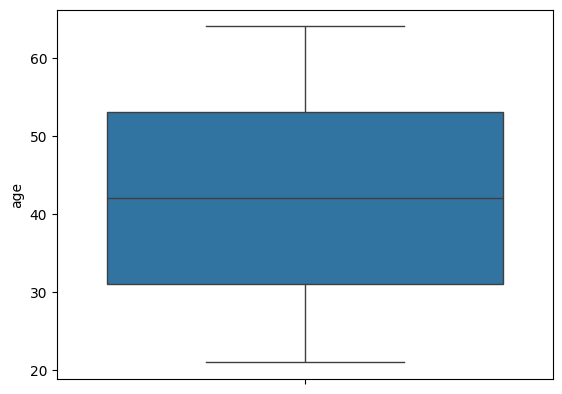

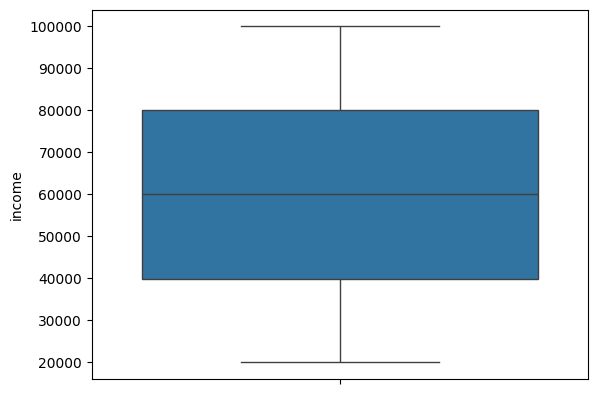

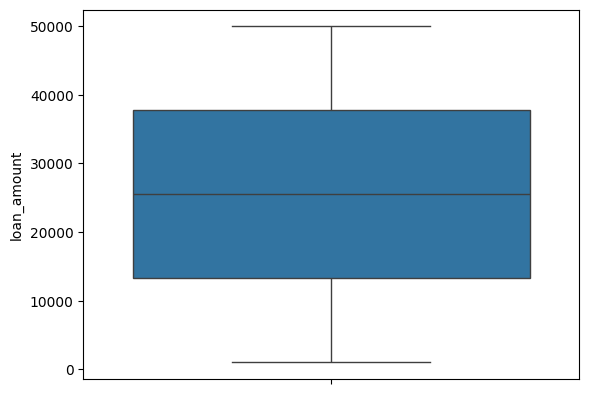

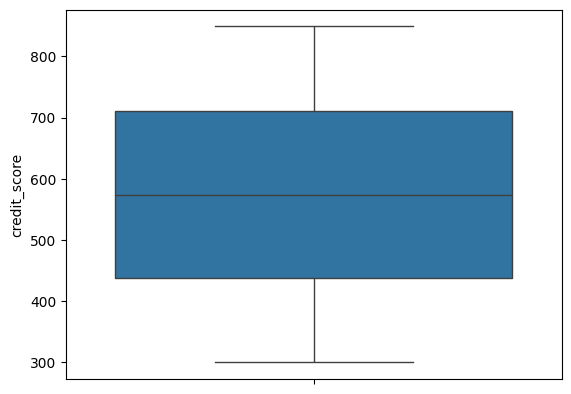

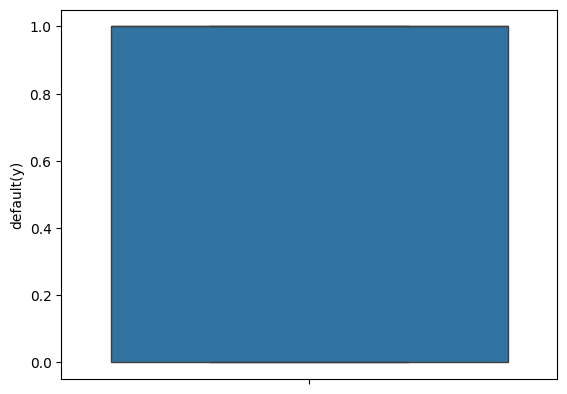

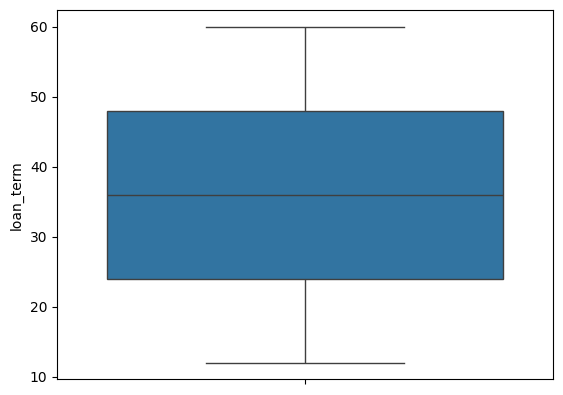

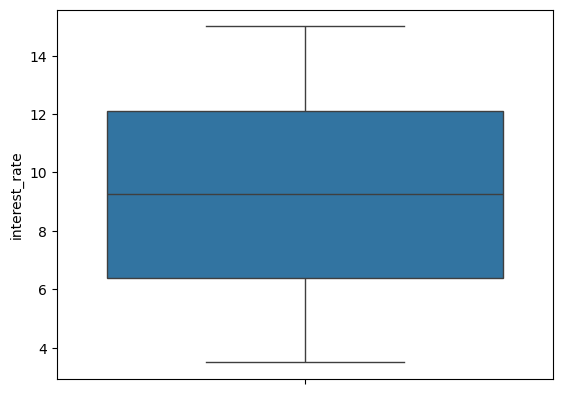

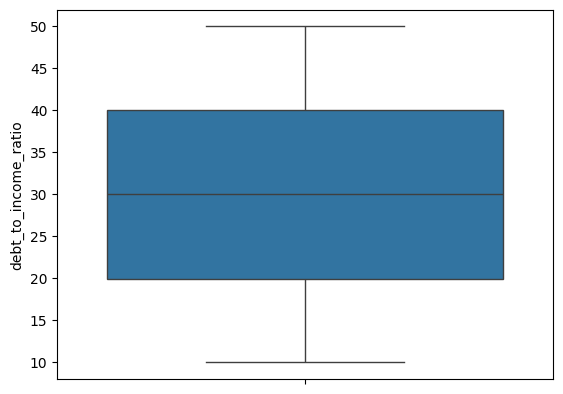

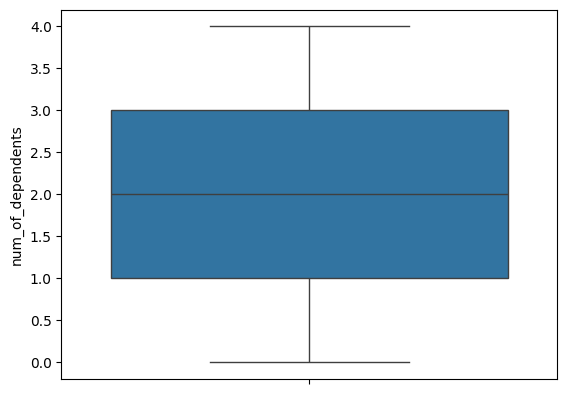

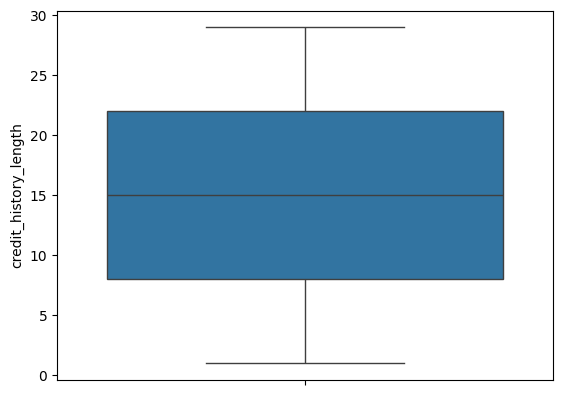

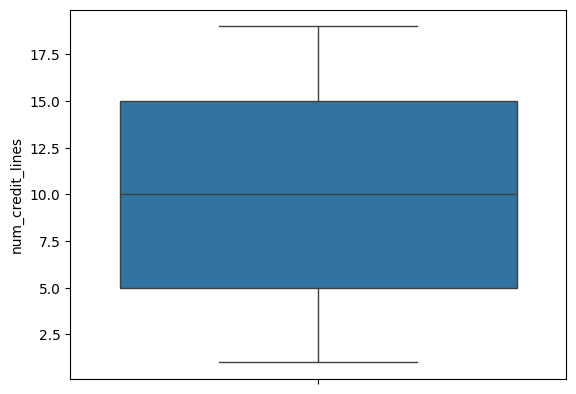

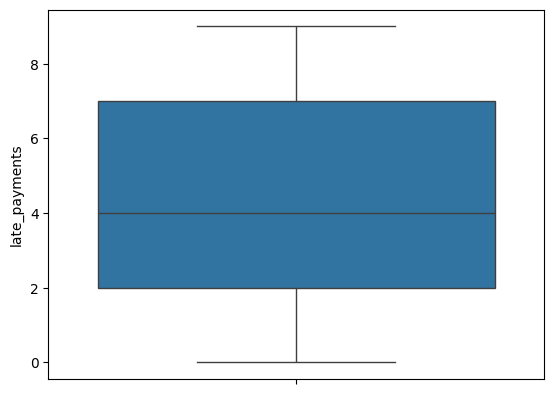

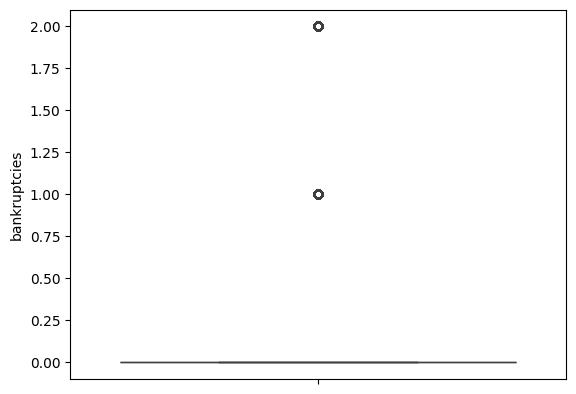

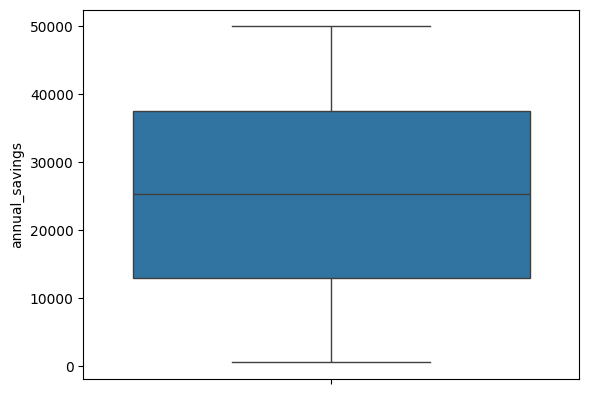

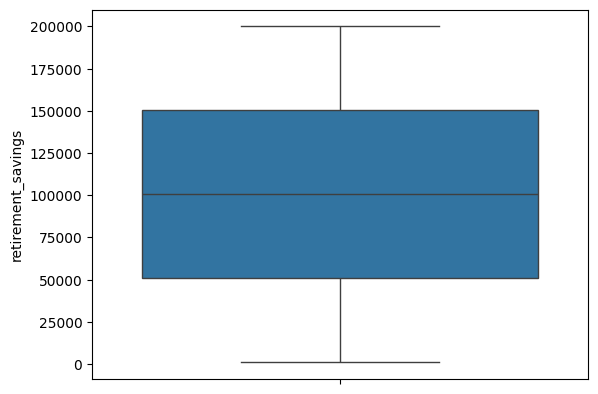

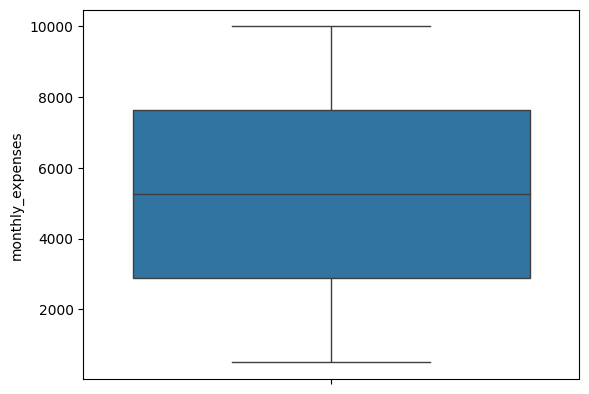

In [11]:
# Checing for Outliers
def boxplots(col):
  sns.boxplot(data[col])
  plt.show()

for i in list(data.select_dtypes(exclude=['object']).columns)[0:]:
  boxplots(i)

None of the features have any outliers. Except for banckruptcies, its a categorical data

In [12]:
data.describe()

,age,income,loan_amount,credit_score,default(y),loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,42.462720,60012.224960,25519.561950,573.806760,0.500940,36.025560,9.254996,29.995874,1.997350,14.975920,10.012660,4.492340,0.059720,25221.936980,100743.644020,5253.344490
std,12.690258,23093.209173,14136.260198,158.581563,0.500002,16.964051,3.318369,11.563967,1.417576,8.369603,5.470983,2.872665,0.276973,14258.782992,57459.490883,2740.027792
min,21.000000,20000.000000,1000.000000,300.000000,0.000000,12.000000,3.500245,10.000275,0.000000,1.000000,1.000000,0.000000,0.000000,500.000000,1002.000000,500.000000
25%,31.000000,39935.750000,13311.750000,437.000000,0.000000,24.000000,6.377951,19.973035,1.000000,8.000000,5.000000,2.000000,0.000000,12912.750000,50855.500000,2874.750000
50%,42.000000,60175.000000,25583.000000,574.000000,1.000000,36.000000,9.269498,30.007073,2.000000,15.000000,10.000000,4.000000,0.000000,25230.500000,100694.500000,5263.000000
75%,53.000000,79991.000000,37771.000000,710.000000,1.000000,48.000000,12.113304,40.034245,3.000000,22.000000,15.000000,7.000000,0.000000,37514.000000,150403.750000,7631.000000
max,64.000000,99998.000000,49999.000000,849.000000,1.000000,60.000000,14.999895,49.999915,4.000000,29.000000,19.000000,9.000000,2.000000,49999.000000,199997.000000,9999.000000


bankruptcies (integer, 0–2)- Categorical data, Number of past bankruptcies. Even a single bankruptcy significantly increases the risk of default.

Bankruptcies: min is 0 and max is 2 but the 25th, 50th and 75th percentile values are all 0, which shows that the data is not balanced in bankruptcies.



In [13]:
eda_bankruptcies = data['bankruptcies'].value_counts()
eda_bankruptcies

,count
bankruptcies,
0,95056
1,3916
2,1028


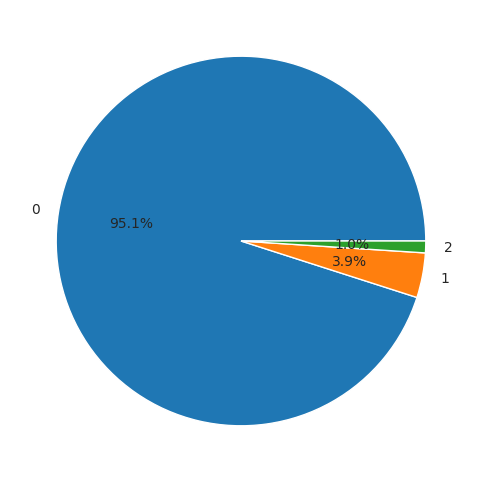

In [14]:
sns.set_style("whitegrid") # Set style for chart
plt.figure(figsize=(6,6)) # Set figure size
plt.pie(eda_bankruptcies, labels=eda_bankruptcies.index, autopct='%1.1f%%') # Create pie chart
plt.show() # Show chart

95% of the customers have 0 bankruptcies, ~4% have 1 and only 1% of them have 2 bankrupticies. This feature does not have much pattern that can significantly impact the dependent variable, so it can be removed from the dataset.

Check the data groupby bankruptcy 1 and 2 and check the 'default' value

In [15]:
data[['bankruptcies','default(y)']].groupby(['bankruptcies']).value_counts()

bankruptcies  default(y)
0             1             47606
              0             47450
1             0              1966
              1              1950
2             1               538
              0               490
Name: count, dtype: int64

The data relating to 0 bankruptcies is almost equally distributed between the two classes of dependent variable. But, if the customer is bankrupt the risk of default should be high, but here the data is equally distributed for both classes of default.

This shows there is not much significance of bankruptcy on the default value.

In [16]:
data.where(data['bankruptcies'] == 1).dropna().describe()

,age,income,loan_amount,credit_score,default(y),loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses
count,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.0,3916.000000,3916.000000,3916.000000
mean,42.397344,59199.168284,25758.671093,573.166752,0.497957,36.091931,9.317748,30.112741,2.018897,14.946885,9.874617,4.426966,1.0,24766.550562,100944.833504,5202.433606
std,12.692912,22960.867742,14172.407524,158.999037,0.500060,16.987644,3.309308,11.568782,1.411556,8.374152,5.454782,2.873142,0.0,14086.672730,57646.846295,2747.188932
min,21.000000,20041.000000,1005.000000,300.000000,0.000000,12.000000,3.501612,10.009198,0.000000,1.000000,1.000000,0.000000,1.0,529.000000,1038.000000,500.000000
25%,31.000000,39148.500000,13399.000000,435.000000,0.000000,24.000000,6.510409,20.106817,1.000000,8.000000,5.000000,2.000000,1.0,12682.750000,50646.000000,2814.750000
50%,42.000000,58549.500000,26201.000000,578.000000,0.000000,36.000000,9.424744,30.163939,2.000000,15.000000,10.000000,4.000000,1.0,24302.000000,99689.500000,5197.500000
75%,54.000000,79017.500000,37891.000000,709.000000,1.000000,48.000000,12.158823,40.103724,3.000000,22.000000,15.000000,7.000000,1.0,36664.000000,150910.750000,7570.250000
max,64.000000,99985.000000,49988.000000,849.000000,1.000000,60.000000,14.997266,49.995105,4.000000,29.000000,19.000000,9.000000,1.0,49990.000000,199972.000000,9998.000000


Age: (integer, 21–65 years)- Age of the borrower. Older individuals may have a longer
credit history, impacting risk assessment. There are no null values in this feature and from the describe function above, the min and max values show that there are no outliers in the data.

In [17]:
data['age'].value_counts()

,count
age,
58,2348
51,2348
23,2346
28,2335
40,2328
33,2327
39,2327
48,2324
38,2319


Data is evenly distributed for all the ages within the range of 20-60

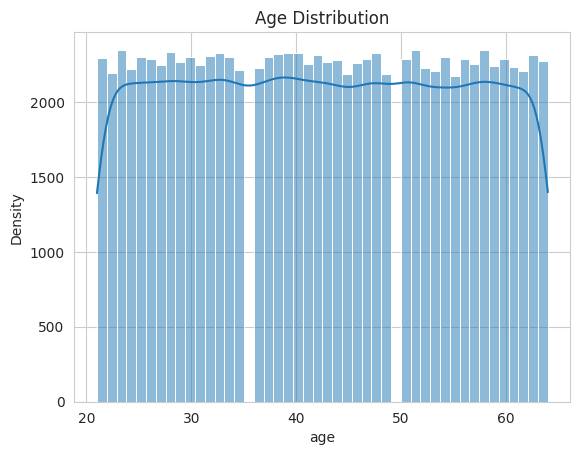

In [18]:
sns.histplot(data['age'], kde=True)
plt.xlabel('age')
plt.ylabel('Density')
plt.title('Age Distribution')
plt.show()

In [19]:
data[['age','default(y)']].groupby(['default(y)']).describe()

age                                                    
              count       mean        std   min   25%   50%   75%   max
default(y)                                                             
0           49906.0  42.448944  12.671567  21.0  32.0  42.0  53.0  64.0
1           50094.0  42.476444  12.708963  21.0  31.0  42.0  53.0  64.0

In [20]:
data['age'].where(data['default(y)'] == 1).value_counts().sort_values()

,count
age,
55.0,1054
22.0,1066
45.0,1080
43.0,1094
24.0,1099
35.0,1101
52.0,1104
54.0,1106
36.0,1112


In [21]:
#Creating bins for the age
data['age_range'] = pd.cut(data['age'], bins=[20,30,40,50,60,64],labels=['20-30','30-40','40-50','50-60','60+'])
data.head()

,age,income,loan_amount,credit_score,employment_status,default(y),loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,education_level,home_ownership,marital_status,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses,age_range
0,38,71440,27069,689,self-employed,1,36,9.937874,31.046101,0,high_school,rent,married,7,6,1,1,25259,195208,6037,30-40
1,36,90200,14895,578,employed,0,48,13.624882,21.845252,0,high_school,own,married,11,16,8,0,40761,152999,4064,30-40
2,47,85896,2613,352,employed,1,12,6.676366,12.562405,1,bachelor,mortgage,divorced,24,2,2,0,34857,67487,2848,40-50
3,38,20121,3163,622,unemployed,0,48,12.833366,17.144545,1,master,own,married,12,4,6,1,16048,98869,7721,30-40
4,44,77529,37731,615,self-employed,0,12,4.111636,35.892430,3,high_school,own,single,27,7,5,0,5668,42397,8009,40-50


In [22]:
age_range = data['age_range'].where(data['default(y)'] == 1).value_counts().sort_values()
age_range

,count
age_range,
60+,4612
50-60,11275
40-50,11292
20-30,11407
30-40,11508


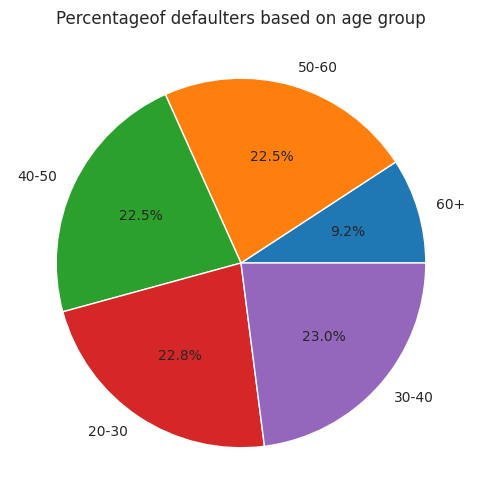

In [23]:
sns.set_style("whitegrid") # Set style for chart
plt.figure(figsize=(6,6)) # Set figure size
plt.pie(age_range, labels=age_range.index, autopct='%1.1f%%') # Create pie chart
plt.title("Percentageof defaulters based on age group")
plt.show() # Show chart

The customers in the age group of 30-40 have maximum number of defaulters, followed by the 20-30 age group. In general the younger age groups have more defaulters compared to the older age group customers.

In [24]:
# Age vs monthly expenses
data[['age_range','income','monthly_expenses', 'annual_savings', 'retirement_savings']].groupby(['age_range']).mean()

,income,monthly_expenses,annual_savings,retirement_savings
age_range,,,,
20-30,59906.821694,5278.635749,25455.615074,101089.750626
30-40,59974.487247,5219.081237,25226.499083,100778.736810
40-50,60036.252750,5256.485620,25170.947647,100846.855489
50-60,60277.892835,5266.334466,25086.725051,100352.293523
60+,59646.423299,5235.920528,25087.929284,100504.896475


The average income is highest for 50-60 age group, however the average monthly expenses, annual savings and retirement savings are the highest for 20-30 age group

income (integer $20,000–$100,000)- Annual income of the borrower. Higher income
generally reduces the risk of default. NO null values and the average income is about $60,000. The min and max values in the describe function and the box plot show that the data is with in the range and does not have any outliers.

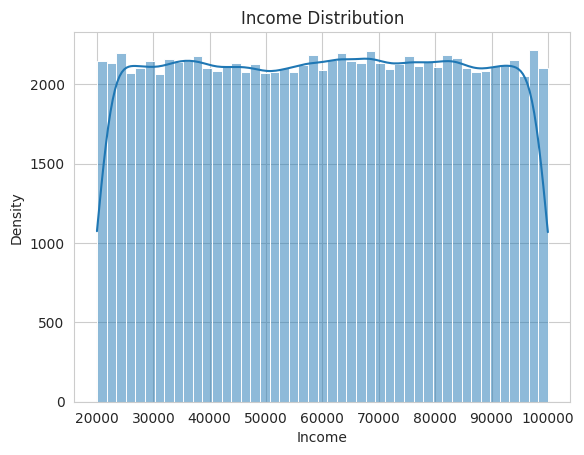

In [25]:
sns.histplot(data['income'], kde=True)
plt.xlabel('Income')
plt.ylabel('Density')
plt.title('Income Distribution')
plt.show()

Income is also uniformly distributed across the dataset

In [26]:
data['income'].where(data['default(y)'] == 1).dropna().describe()

,income
count,50094.000000
mean,60107.555615
std,23075.474607
min,20000.000000
25%,40016.500000
50%,60344.000000
75%,80058.750000
max,99997.000000


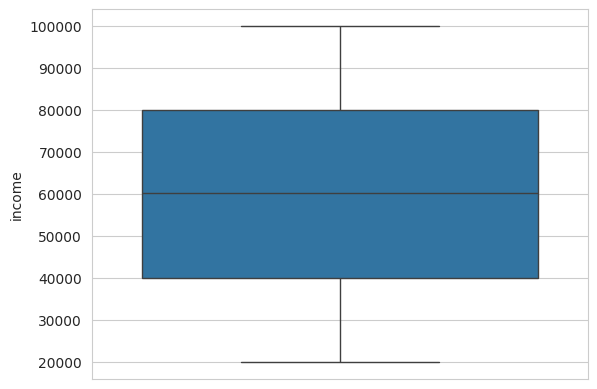

In [27]:
# Checking for outliers using boxplot
sns.boxplot(data['income'])
plt.show()

No outliers in the boxplot. Checking using IQR

In [28]:
def detect_outliers(df, feature):
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    print(upper_bound)
    print(lower_bound)
    # Identify outliers
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    if outliers.empty:
        print("No outliers found.")
    else:
        print("Outliers found:")
    return outliers


In [29]:
print(detect_outliers(data, 'income'))

140073.875
-20147.125
No outliers found.
Empty DataFrame
Columns: [age, income, loan_amount, credit_score, employment_status, default(y), loan_term, interest_rate, debt_to_income_ratio, num_of_dependents, education_level, home_ownership, marital_status, credit_history_length, num_credit_lines, late_payments, bankruptcies, annual_savings, retirement_savings, monthly_expenses, age_range]
Index: []


No outliers found in income feature.



In [30]:
data.columns

Index(['age', 'income', 'loan_amount', 'credit_score', 'employment_status',
       'default(y)', 'loan_term', 'interest_rate', 'debt_to_income_ratio',
       'num_of_dependents', 'education_level', 'home_ownership',
       'marital_status', 'credit_history_length', 'num_credit_lines',
       'late_payments', 'bankruptcies', 'annual_savings', 'retirement_savings',
       'monthly_expenses', 'age_range'],
      dtype='object')

Check relation between income and default(y), loan_amount, monthly expenses, age-range, annual savings

In [31]:
# income and default(y)
eda_income_default = data[['income','default(y)']].groupby(['default(y)']).describe()
eda_income_default

income                                                          \
              count          mean           std      min       25%      50%   
default(y)                                                                    
0           49906.0  59916.535186  23110.832593  20000.0  39795.25  59981.5   
1           50094.0  60107.555615  23075.474607  20000.0  40016.50  60344.0   

                               
                 75%      max  
default(y)                     
0           79922.75  99998.0  
1           80058.75  99997.0

The average income and the count of customers who are defaulters is more compared to non defaulters

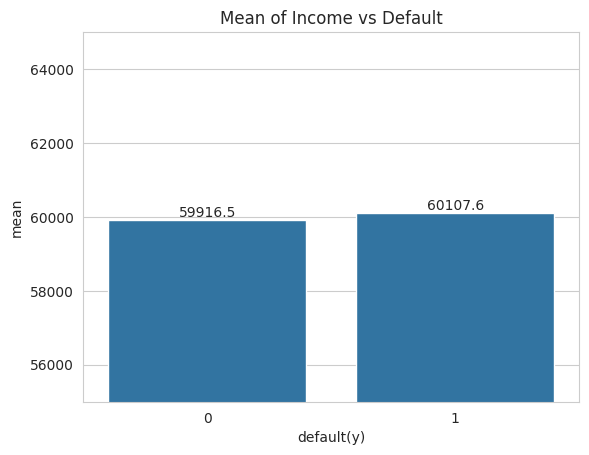

In [32]:
plt.ylim(bottom = 55000, top=65000)
ax = sns.barplot(x=eda_income_default.index, y = eda_income_default['income']['mean'])
ax.bar_label(ax.containers[0])
plt.title("Mean of Income vs Default")
plt.show()

Income and monthly expenses are continuous numerical variables so we can analyse the relation using a scatter plot

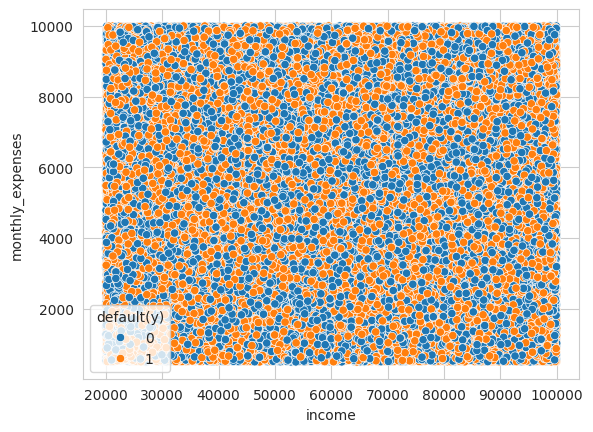

In [33]:
# inocme and monthly_expenses
sns.scatterplot(data=data, x='income', y='monthly_expenses', hue='default(y)')
plt.show()

The scatter plot does not show any relation as the data is uniformly distributed

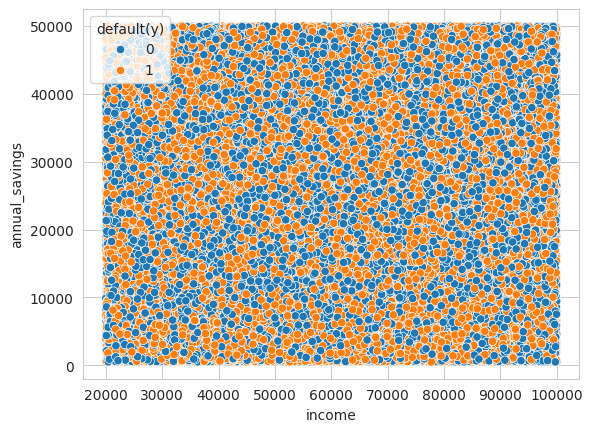

In [34]:
# income and annual savings
sns.scatterplot(data=data, x='income', y='annual_savings', hue='default(y)')
plt.show()

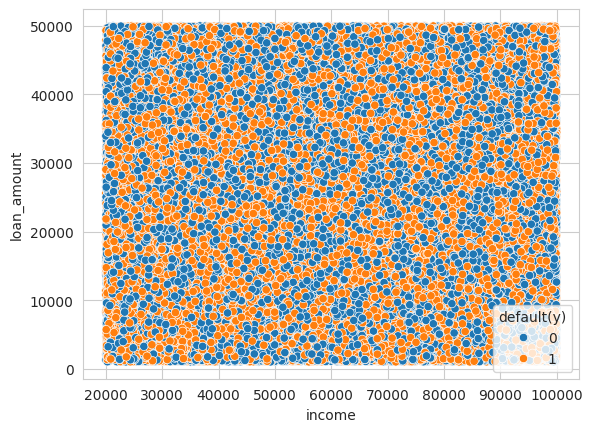

In [35]:
# income loan_amount
sns.scatterplot(data=data, x='income', y='loan_amount', hue='default(y)')
plt.show()

In [36]:
# income and age_range
eda_income_age = data[['income','age_range']].groupby(['age_range']).describe()
eda_income_age

income                                                          \
             count          mean           std      min       25%      50%   
age_range                                                                    
20-30      22781.0  59906.821694  23068.693893  20003.0  39943.00  60029.0   
30-40      22896.0  59974.487247  22996.866256  20000.0  39988.75  60226.5   
40-50      22635.0  60036.252750  23164.959973  20007.0  39933.50  60057.0   
50-60      22666.0  60277.892835  23055.957731  20000.0  40278.25  60556.5   
60+         9022.0  59646.423299  23308.958519  20003.0  38974.50  59575.0   

                              
                75%      max  
age_range                     
20-30      79758.00  99992.0  
30-40      79722.25  99998.0  
40-50      80132.00  99991.0  
50-60      80351.25  99997.0  
60+        79793.25  99962.0

The average income of customer in the age group of 50-60 is the highest.

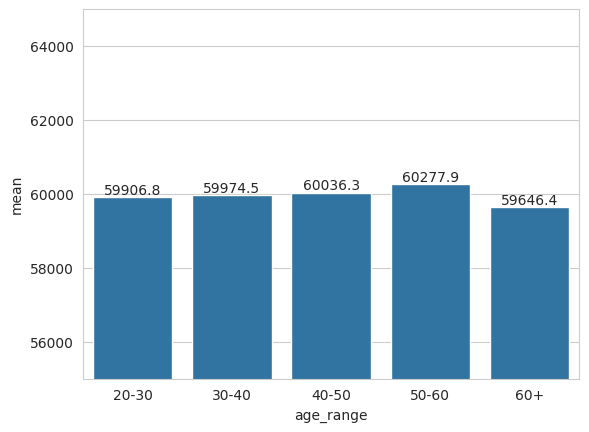

In [37]:
plt.ylim(bottom=55000, top=65000)
ax = sns.barplot(x=eda_income_age.index, y = eda_income_age['income']['mean'])
ax.bar_label(ax.containers[0])
plt.show()

Visualizing the distribution of numerical features

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   age                    100000 non-null  int64   
 1   income                 100000 non-null  int64   
 2   loan_amount            100000 non-null  int64   
 3   credit_score           100000 non-null  int64   
 4   employment_status      100000 non-null  object  
 5   default(y)             100000 non-null  int64   
 6   loan_term              100000 non-null  int64   
 7   interest_rate          100000 non-null  float64 
 8   debt_to_income_ratio   100000 non-null  float64 
 9   num_of_dependents      100000 non-null  int64   
 10  education_level        100000 non-null  object  
 11  home_ownership         100000 non-null  object  
 12  marital_status         100000 non-null  object  
 13  credit_history_length  100000 non-null  int64   
 14  num_credit_lines     

In [39]:
# Getting numerical variables
numeric_features = data.select_dtypes(include=[np.number])
numeric_features_names = numeric_features.columns.tolist()
numeric_features_names

['age',
 'income',
 'loan_amount',
 'credit_score',
 'default(y)',
 'loan_term',
 'interest_rate',
 'debt_to_income_ratio',
 'num_of_dependents',
 'credit_history_length',
 'num_credit_lines',
 'late_payments',
 'bankruptcies',
 'annual_savings',
 'retirement_savings',
 'monthly_expenses']

Removing few features from the numerical features list:
1. age: dont need this as the age range column is more informative
2. default(y): Numeric values but its categorical data
3. num_of_dependents: Numeric values but categorical data
4. bankruptcies: can be considered as categorical data


In [40]:
numeric_features_names.remove('age')
numeric_features_names.remove('default(y)')
numeric_features_names.remove('num_of_dependents')
numeric_features_names.remove('bankruptcies')
numeric_features_names

['income',
 'loan_amount',
 'credit_score',
 'loan_term',
 'interest_rate',
 'debt_to_income_ratio',
 'credit_history_length',
 'num_credit_lines',
 'late_payments',
 'annual_savings',
 'retirement_savings',
 'monthly_expenses']

In [41]:
def plot_col_distribution(col_name):
  plt.figure(figsize=(15,4))
  plt.subplot(1,2,1)
  sns.distplot(data[col_name])

  plt.subplot(1,2,2)
  sns.boxplot(data[col_name])
  print(f"The skewness for the {col_name} is {format(data[col_name].skew())}.")
  print(f"The kurtosis for the {col_name} is {format(data[col_name].kurt())}.")

The skewness for the income is -0.0039944514567729185.
The kurtosis for the income is -1.198309243718842.
The skewness for the loan_amount is -0.004300692684923429.
The kurtosis for the loan_amount is -1.1958588214400137.
The skewness for the credit_score is 0.0045691660807299465.
The kurtosis for the credit_score is -1.1967122772917282.
The skewness for the loan_term is -0.00015577433933864205.
The kurtosis for the loan_term is -1.2982406472575998.
The skewness for the interest_rate is -0.002325380360206001.
The kurtosis for the interest_rate is -1.196594474982596.
The skewness for the debt_to_income_ratio is 0.0021778520278362104.
The kurtosis for the debt_to_income_ratio is -1.2028896746812021.
The skewness for the credit_history_length is 0.0025794608166076404.
The kurtosis for the credit_history_length is -1.2008611344792284.
The skewness for the num_credit_lines is -0.003164536599529195.
The kurtosis for the num_credit_lines is -1.2025892001223417.
The skewness for the late_payme

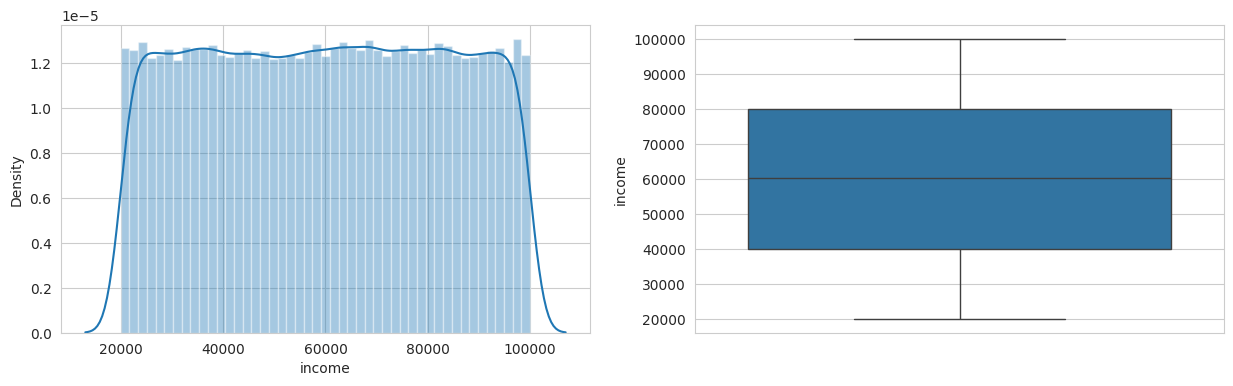

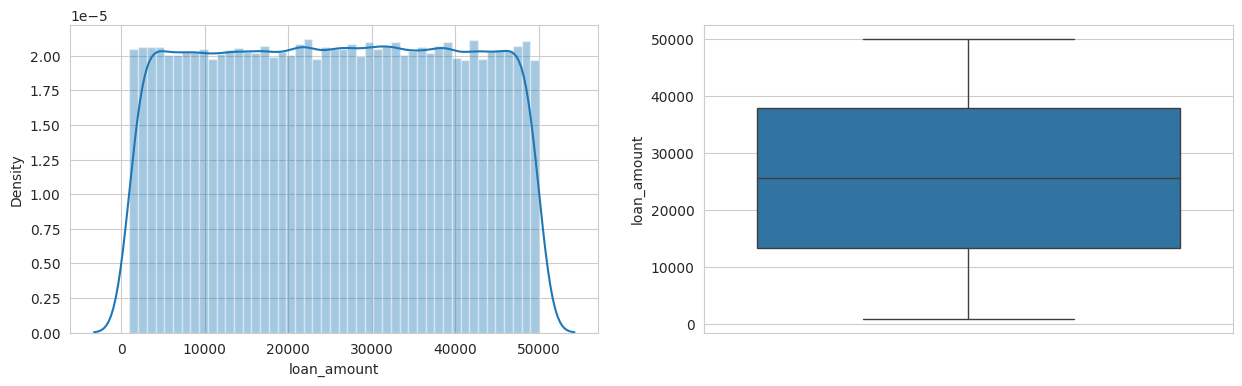

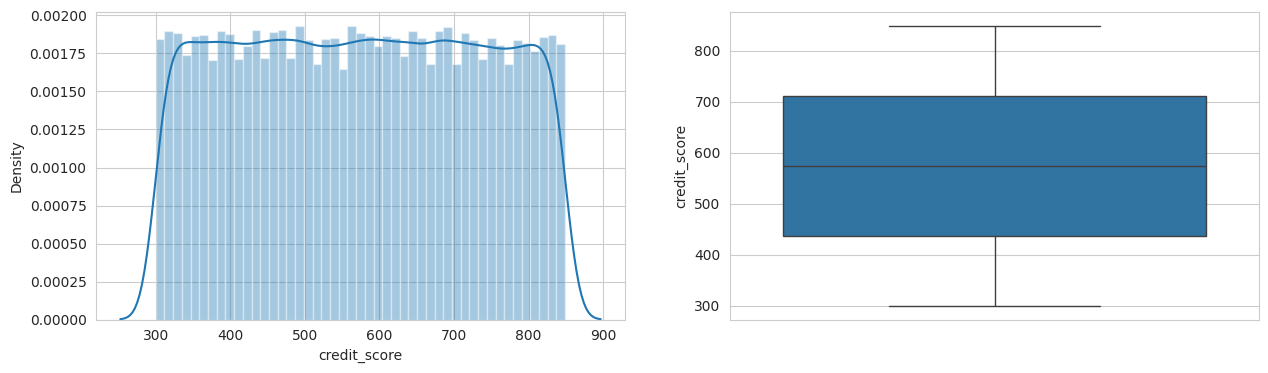

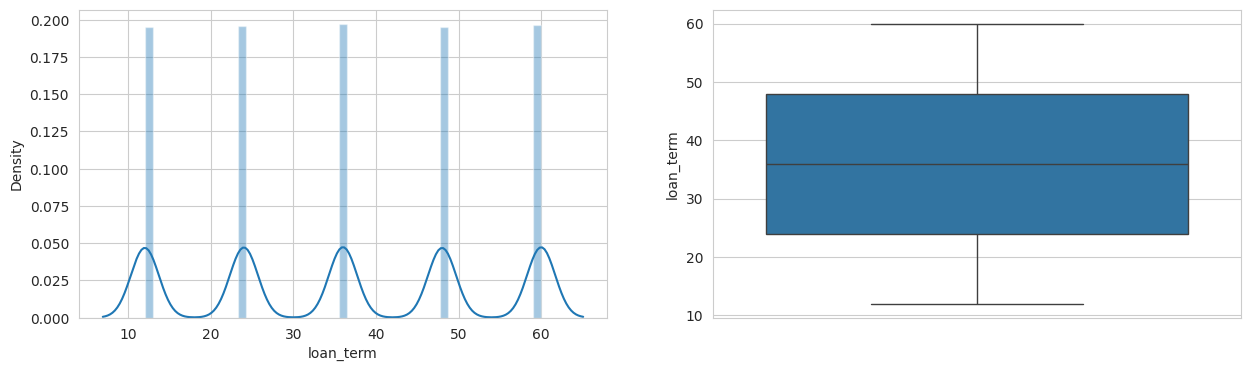

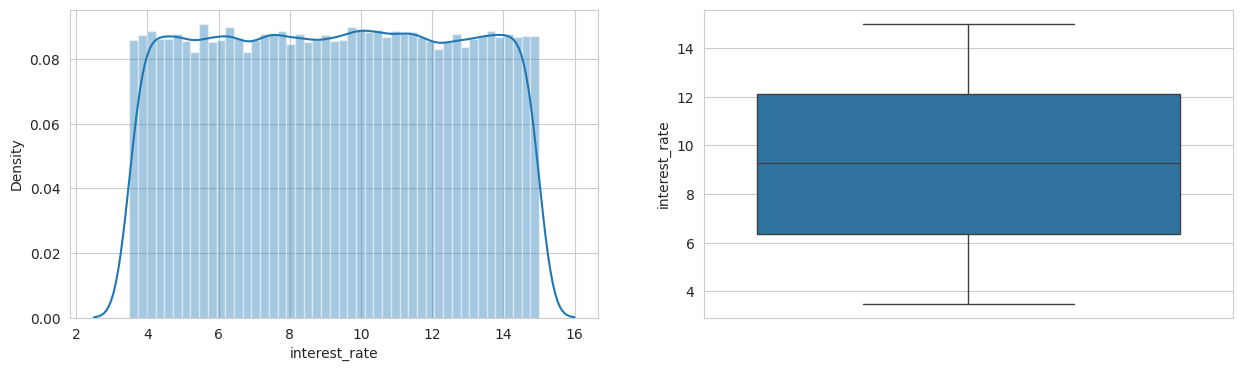

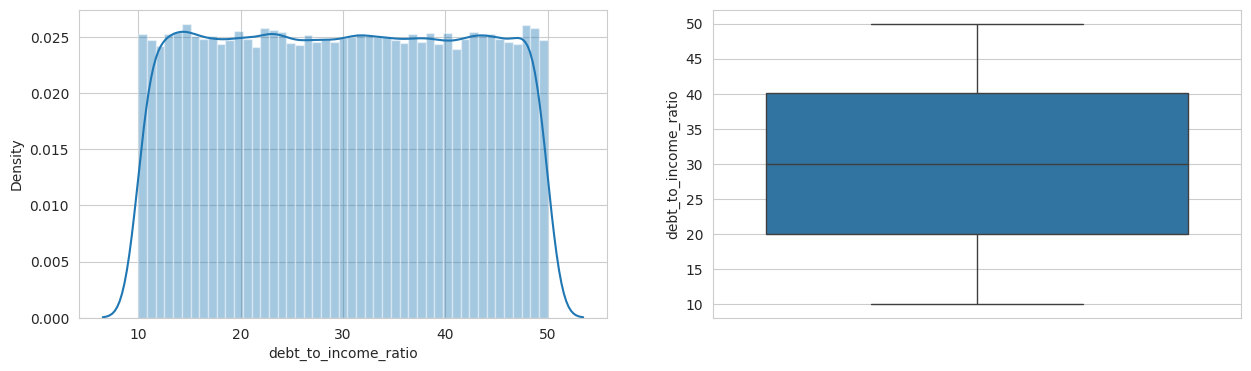

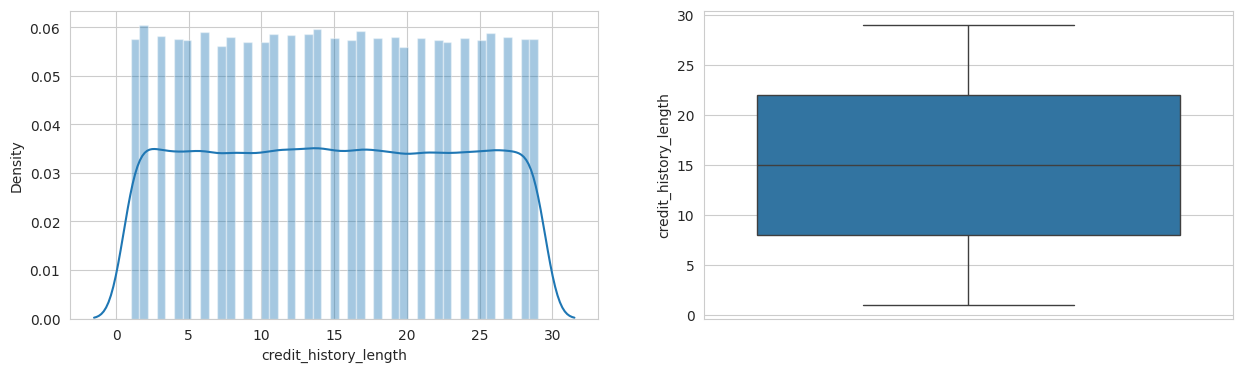

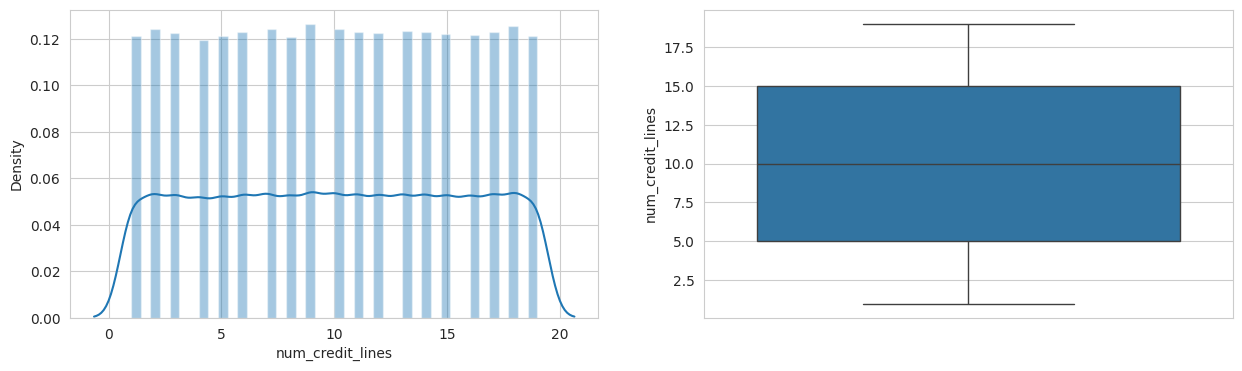

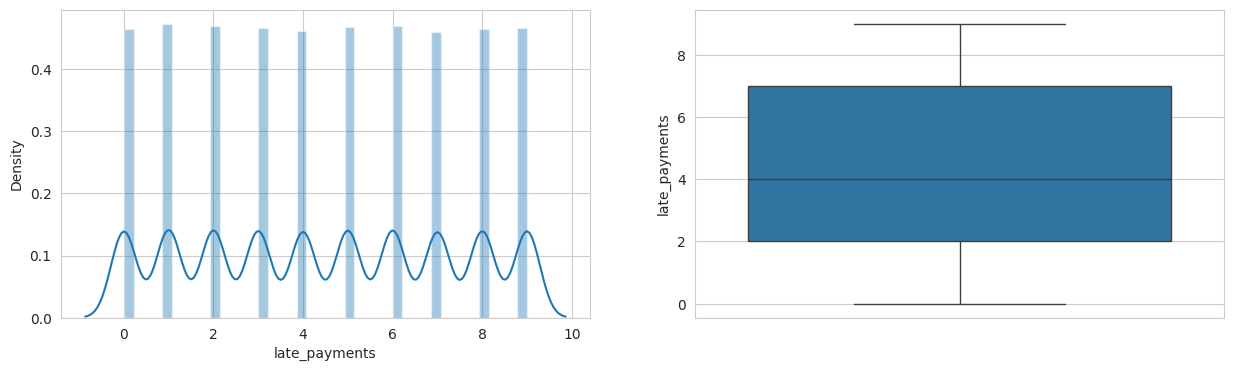

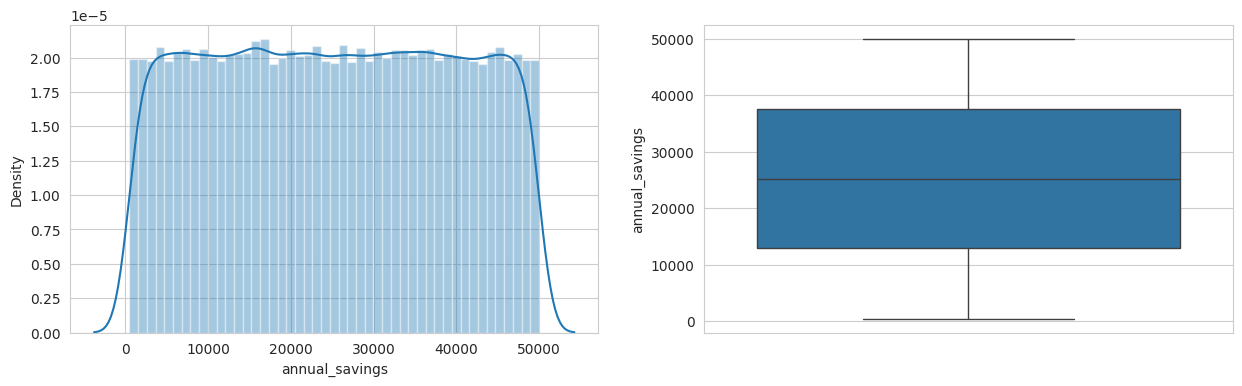

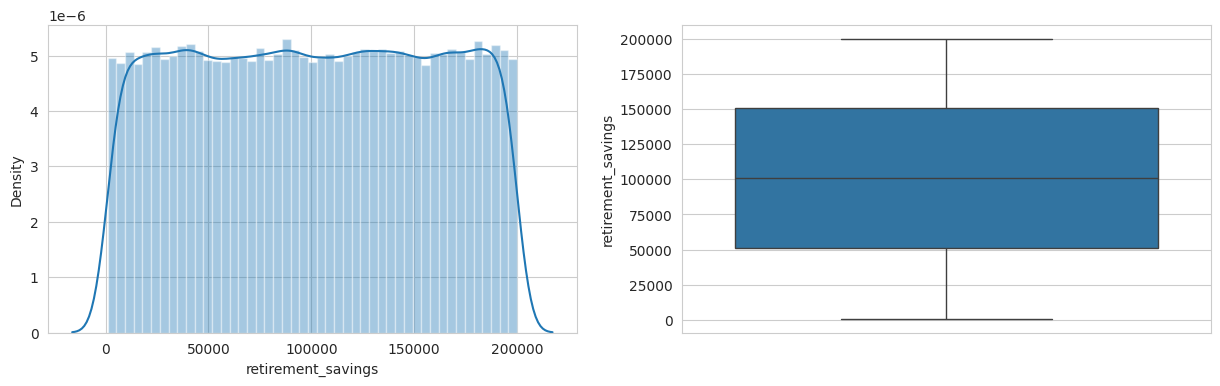

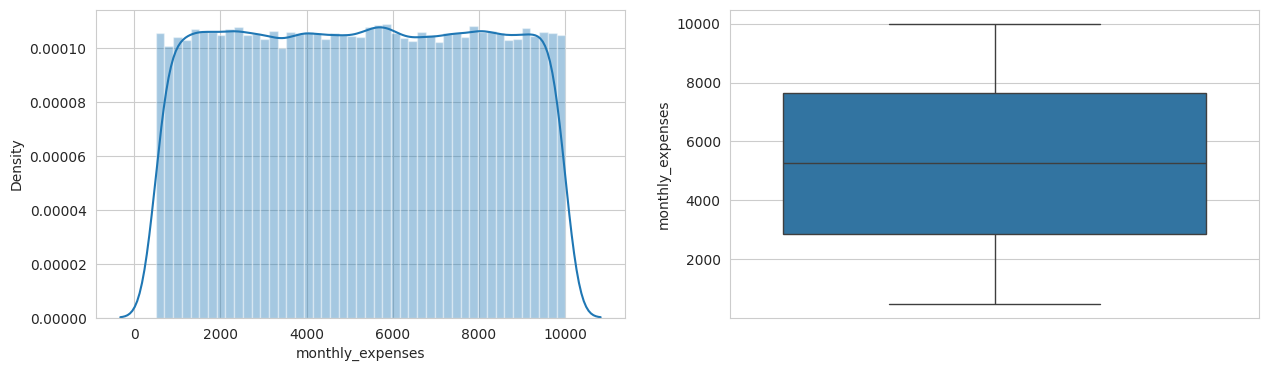

In [42]:
for i in list(numeric_features_names):
  plot_col_distribution(i)

The data is uniformly distributed for all the features, including the continuous data and discrete data. Hense the skewness and kurtosis are near to 0 for all of them.

Auniformly distributed data signifies that all values within the range are equally represented, meaning the data has no inherent bias towards any specific value.

Because of the uniform distribution of the data, there are no outliers in any of the features.

Checking the correlation between these numeric variables using a heat map

In [43]:
num_feat_df = data[numeric_features_names]
num_feat_df = num_feat_df.assign(default=data['default(y)'])
num_feat_df.head()

,income,loan_amount,credit_score,loan_term,interest_rate,debt_to_income_ratio,credit_history_length,num_credit_lines,late_payments,annual_savings,retirement_savings,monthly_expenses,default
0,71440,27069,689,36,9.937874,31.046101,7,6,1,25259,195208,6037,1
1,90200,14895,578,48,13.624882,21.845252,11,16,8,40761,152999,4064,0
2,85896,2613,352,12,6.676366,12.562405,24,2,2,34857,67487,2848,1
3,20121,3163,622,48,12.833366,17.144545,12,4,6,16048,98869,7721,0
4,77529,37731,615,12,4.111636,35.892430,27,7,5,5668,42397,8009,0


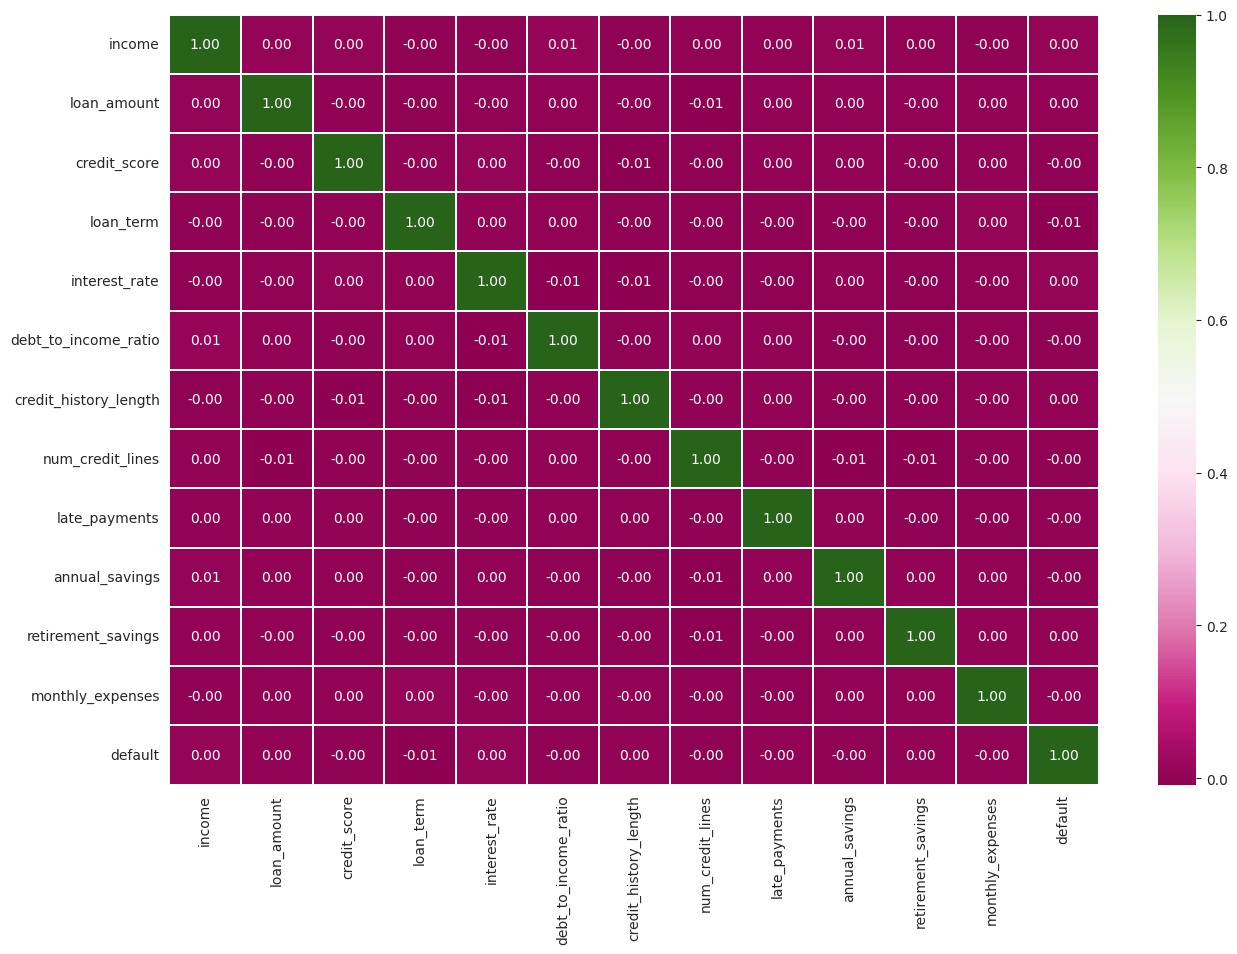

In [44]:
#Correlation plot
fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(num_feat_df.corr(method='spearman'), annot = True, cmap="PiYG", linewidths = 0.1, annot_kws = {'size':10}, fmt = '.2f')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.show()

The dependent variable has a slight negetive correlation with loan_term.

Analysing the categorical variables

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   age                    100000 non-null  int64   
 1   income                 100000 non-null  int64   
 2   loan_amount            100000 non-null  int64   
 3   credit_score           100000 non-null  int64   
 4   employment_status      100000 non-null  object  
 5   default(y)             100000 non-null  int64   
 6   loan_term              100000 non-null  int64   
 7   interest_rate          100000 non-null  float64 
 8   debt_to_income_ratio   100000 non-null  float64 
 9   num_of_dependents      100000 non-null  int64   
 10  education_level        100000 non-null  object  
 11  home_ownership         100000 non-null  object  
 12  marital_status         100000 non-null  object  
 13  credit_history_length  100000 non-null  int64   
 14  num_credit_lines     

In [46]:
# getting the features of object datatype
cat_features = data.select_dtypes(exclude=[np.number])
cat_features_names = cat_features.columns.tolist()
cat_features_names

['employment_status',
 'education_level',
 'home_ownership',
 'marital_status',
 'age_range']

Checking the data distribution in categorical variables

In [47]:
def cat_data_distribution(col_name):
  plt.figure(figsize=(15,8))
  ax = sns.countplot(x=col_name, data=data, hue='default(y)',order = data[col_name].value_counts().index )
  container = ax.containers[0]
  data_0 = int((data['default(y)'].values == 0).sum())
  data_1 = int((data['default(y)'].values == 1).sum())
  counts_0 = data[col_name].where(data['default(y)'] == 0).value_counts()
  count_percent_0 = counts_0 / data_0 * 100
  counts_1 = data[col_name].where(data['default(y)'] == 1).value_counts()
  count_percent_1 = counts_1 / data_1 * 100
  label_0 = [f'{lbl[0]} ({lbl[1]:.1f}%)' for lbl in zip(counts_0, count_percent_0)]
  label_1 = [f'{lbl[0]} ({lbl[1]:.1f}%)' for lbl in zip(counts_1, count_percent_1)]
  #print(label_0)
  #print(label_1)
  labels = [f"{'':<30}{lbl}" for lbl in zip(label_0,label_1)]

  ax.bar_label(container, labels=labels,label_type='edge')
  plt.show()

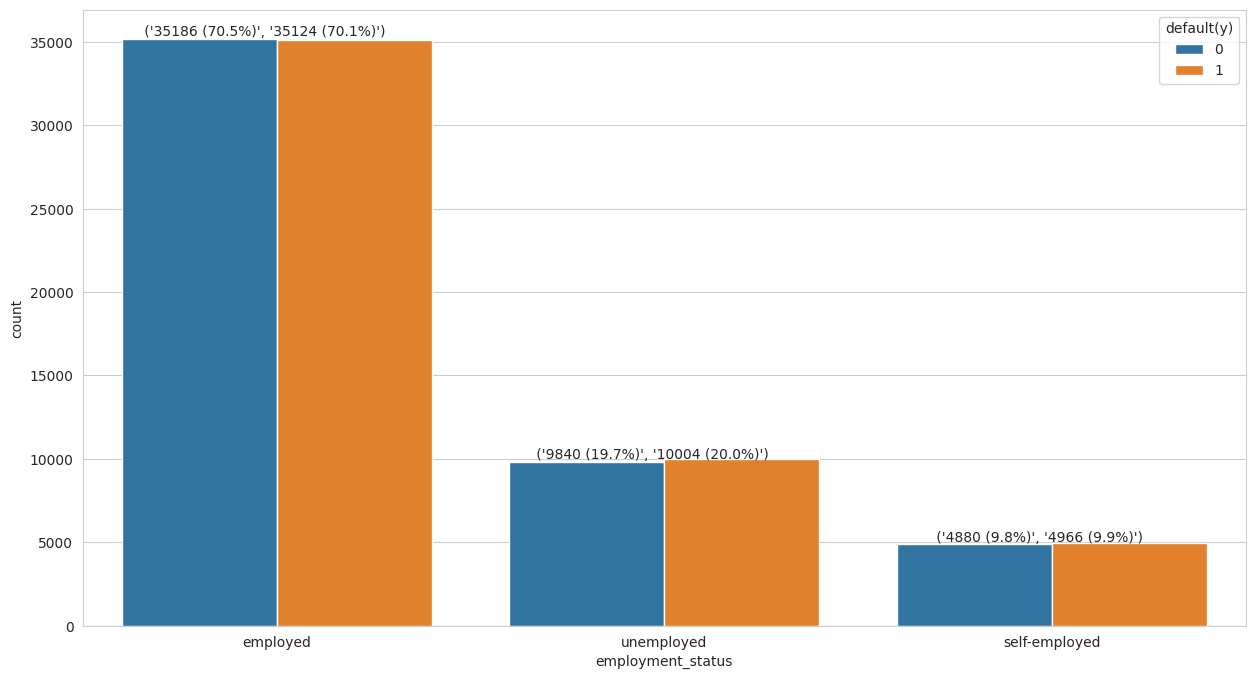

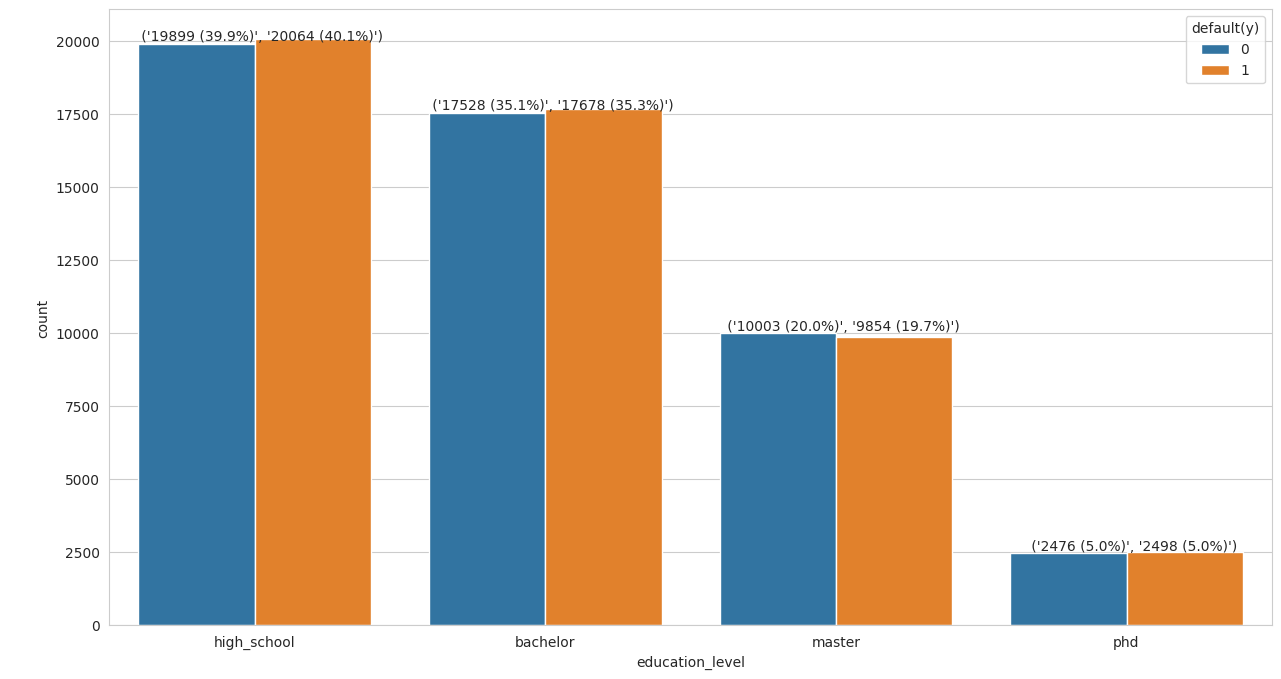

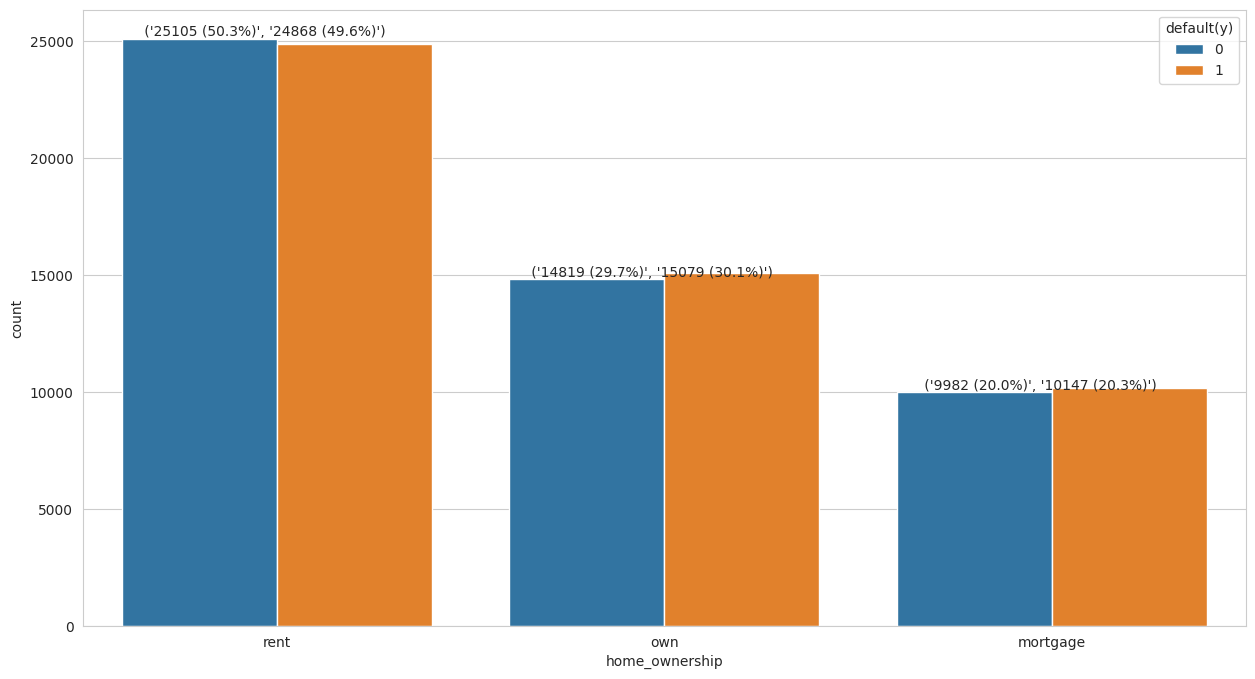

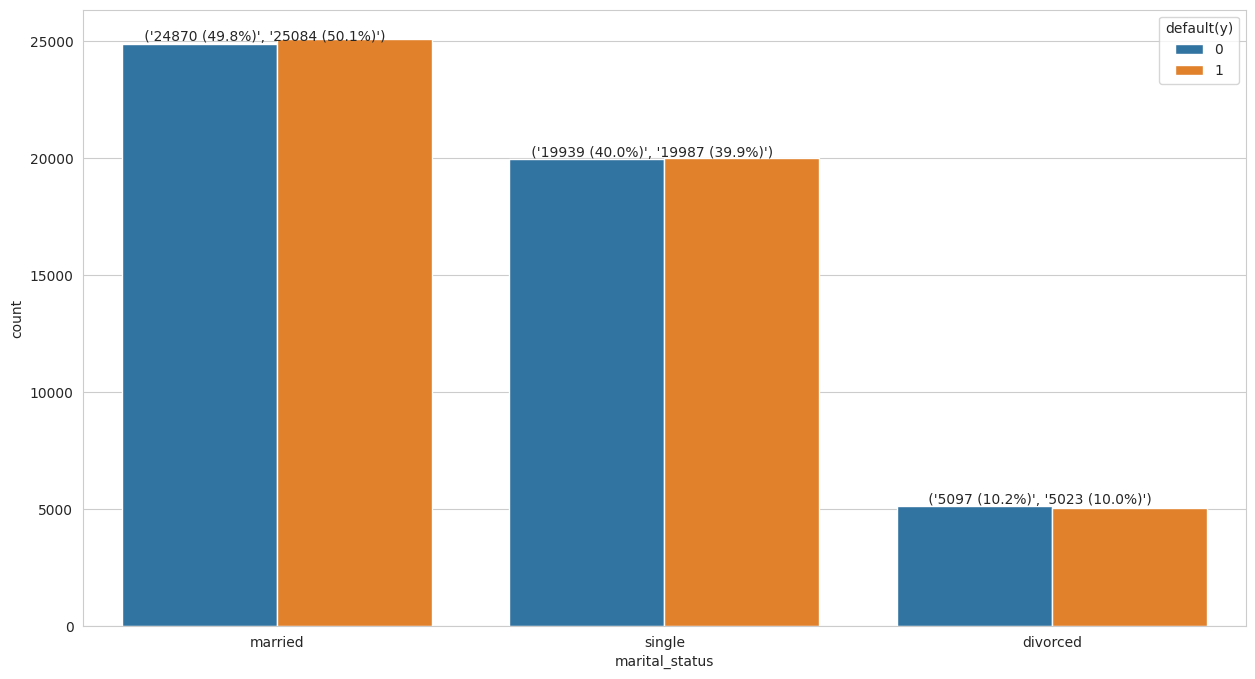

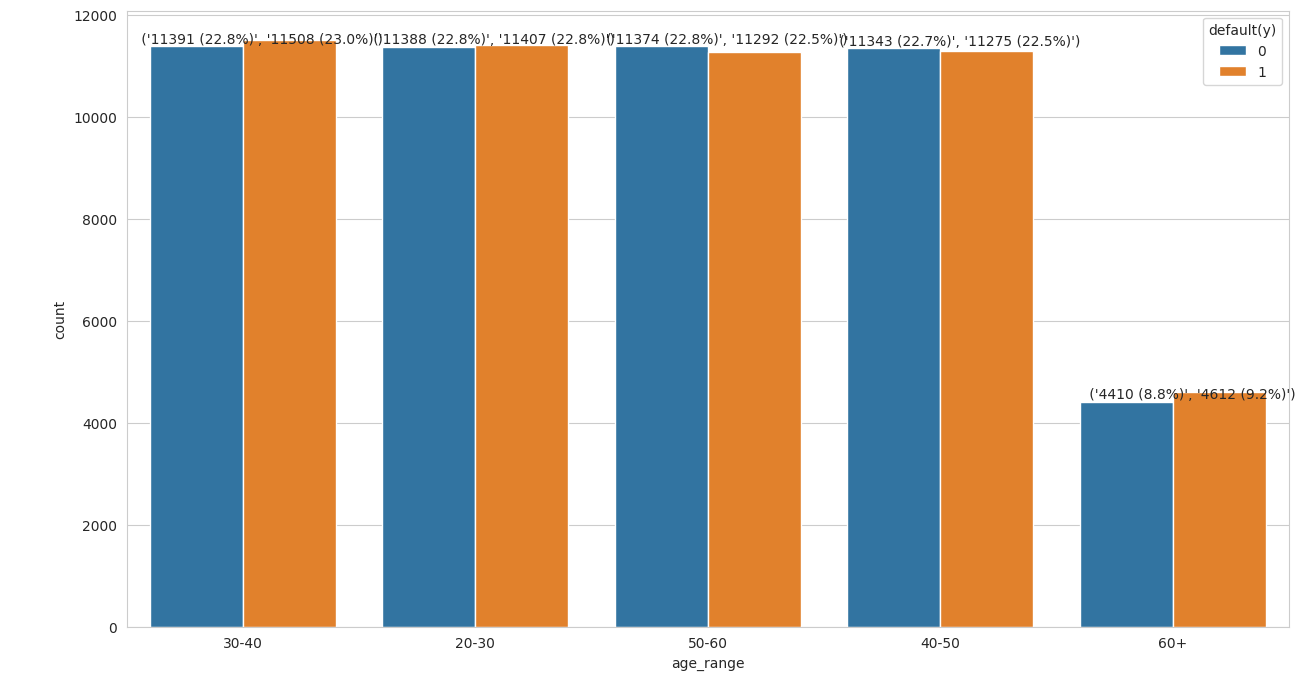

In [48]:
for i in cat_features_names:
  cat_data_distribution(i)

The data distribution of categorical variables with respect to the dependent variable, for the default value 0 and 1, the data is almost equally distributed.

Encoding the categorical features using LabelEncoder

In [49]:
from sklearn.preprocessing import LabelEncoder

def label_encoder(feat):
  le = LabelEncoder()
  le.fit(feat)
  keys = le.classes_
  values = le.transform(le.classes_)
  dictionary = dict(zip(keys, values))
  print(feat.name, dictionary)
  return le.transform(feat)

In [50]:
data['employment_status'] = label_encoder(data['employment_status'])
data['education_level'] = label_encoder(data['education_level'])
data['home_ownership'] = label_encoder(data['home_ownership'])
data['marital_status'] = label_encoder(data['marital_status'])
data['age_range'] = label_encoder(data['age_range'])

employment_status {'employed': np.int64(0), 'self-employed': np.int64(1), 'unemployed': np.int64(2)}
education_level {'bachelor': np.int64(0), 'high_school': np.int64(1), 'master': np.int64(2), 'phd': np.int64(3)}
home_ownership {'mortgage': np.int64(0), 'own': np.int64(1), 'rent': np.int64(2)}
marital_status {'divorced': np.int64(0), 'married': np.int64(1), 'single': np.int64(2)}
age_range {'20-30': np.int64(0), '30-40': np.int64(1), '40-50': np.int64(2), '50-60': np.int64(3), '60+': np.int64(4)}


In [51]:
data.head()

,age,income,loan_amount,credit_score,employment_status,default(y),loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,education_level,home_ownership,marital_status,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses,age_range
0,38,71440,27069,689,1,1,36,9.937874,31.046101,0,1,2,1,7,6,1,1,25259,195208,6037,1
1,36,90200,14895,578,0,0,48,13.624882,21.845252,0,1,1,1,11,16,8,0,40761,152999,4064,1
2,47,85896,2613,352,0,1,12,6.676366,12.562405,1,0,0,0,24,2,2,0,34857,67487,2848,2
3,38,20121,3163,622,2,0,48,12.833366,17.144545,1,2,1,1,12,4,6,1,16048,98869,7721,1
4,44,77529,37731,615,1,0,12,4.111636,35.892430,3,1,1,2,27,7,5,0,5668,42397,8009,2


Checking correlation of all the features

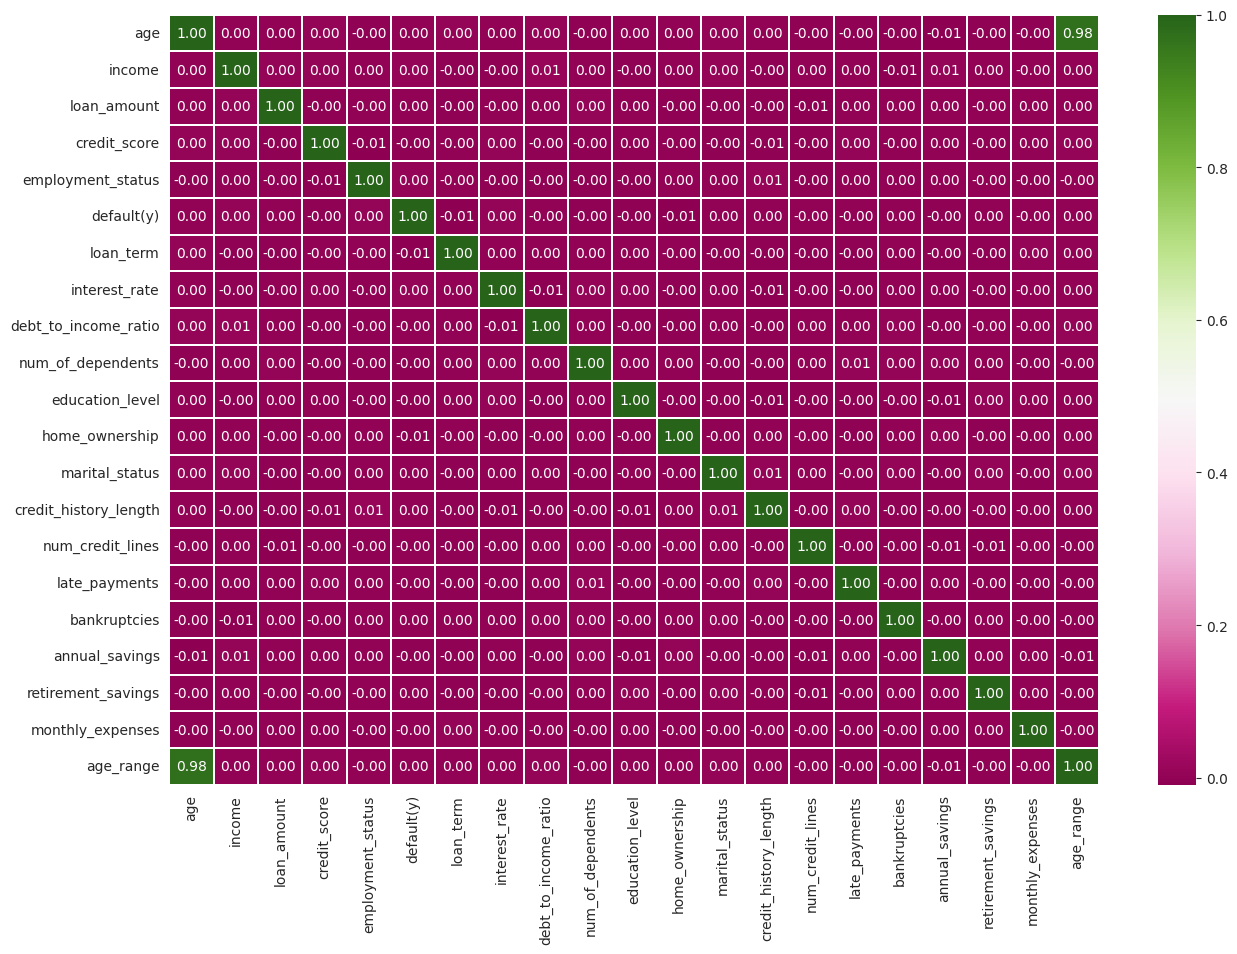

In [52]:
#Correlation plot
fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(data.corr(method='spearman'), annot = True, cmap="PiYG", linewidths = 0.1, annot_kws = {'size':10}, fmt = '.2f')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.show()

The dependent variable default(y) has a slight negetive correlation of -0.01 to loan_term and home_ownership

income, loan_amount, credit_score vs default(y) compare the differences.

In [53]:
data['income'].groupby(data['default(y)']).describe()

,count,mean,std,min,25%,50%,75%,max
default(y),,,,,,,,
0,49906.0,59916.535186,23110.832593,20000.0,39795.25,59981.5,79922.75,99998.0
1,50094.0,60107.555615,23075.474607,20000.0,40016.50,60344.0,80058.75,99997.0


The difference between defaulters and non defaulters for income is the average income of defaulters is more than the non defaulters.

In [54]:
data['loan_amount'].groupby(data['default(y)']).describe()

,count,mean,std,min,25%,50%,75%,max
default(y),,,,,,,,
0,49906.0,25505.196670,14132.360881,1000.0,13364.5,25580.5,37701.75,49999.0
1,50094.0,25533.873318,14140.270361,1000.0,13268.0,25584.0,37831.50,49999.0


There is not much difference of loan amount for defaulters and non defaulters as the mean of the loan amount for defaulters and non defaulters is very close.  

In [55]:
data['credit_score'].groupby(data['default(y)']).describe()

,count,mean,std,min,25%,50%,75%,max
default(y),,,,,,,,
0,49906.0,574.010800,158.590098,300.0,437.0,575.0,711.0,849.0
1,50094.0,573.603485,158.574381,300.0,437.0,573.0,710.0,849.0


No significance difference between the average credit score of defaulters and non defaulters.

As the overall data is uniformly distributed, there is no significant difference between defaulters and non defaulters for any of the key features.

Binning the credit score values to get more insights

In [56]:
#Creating bins for the credit score
data['credit_score_range'] = pd.cut(data['credit_score'], bins=[300,350,400,450,500,550,600,650,700,750,800,850],labels=['300-350','350-400','400-450','450-500','500-550','550-600','600-650','650-700','700-750','750-800','800-850'])
data.head()

,age,income,loan_amount,credit_score,employment_status,default(y),loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,education_level,home_ownership,marital_status,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses,age_range,credit_score_range
0,38,71440,27069,689,1,1,36,9.937874,31.046101,0,1,2,1,7,6,1,1,25259,195208,6037,1,650-700
1,36,90200,14895,578,0,0,48,13.624882,21.845252,0,1,1,1,11,16,8,0,40761,152999,4064,1,550-600
2,47,85896,2613,352,0,1,12,6.676366,12.562405,1,0,0,0,24,2,2,0,34857,67487,2848,2,350-400
3,38,20121,3163,622,2,0,48,12.833366,17.144545,1,2,1,1,12,4,6,1,16048,98869,7721,1,600-650
4,44,77529,37731,615,1,0,12,4.111636,35.892430,3,1,1,2,27,7,5,0,5668,42397,8009,2,600-650


In [57]:
credit_score_range_1 = data['credit_score_range'].where(data['default(y)'] == 1).value_counts().sort_values()
credit_score_range_1

,count
credit_score_range,
800-850,4408
750-800,4470
400-450,4502
500-550,4518
650-700,4543
700-750,4558
600-650,4570
300-350,4573
350-400,4582


In [58]:
credit_score_range_0 = data['credit_score_range'].where(data['default(y)'] == 0).value_counts().sort_values()
credit_score_range_0

,count
credit_score_range,
750-800,4421
800-850,4463
350-400,4503
700-750,4505
500-550,4530
450-500,4547
550-600,4553
650-700,4566
400-450,4576


max number of defaulters are having a credit score of 450-500, maximum number of non defaulters are having a credit score of 300-350.

Generally, a higher credit score indicates a lower risk of fraud but in this data its a bit different. The credit scores of defaulters is higher than the credit score of non defaulters.

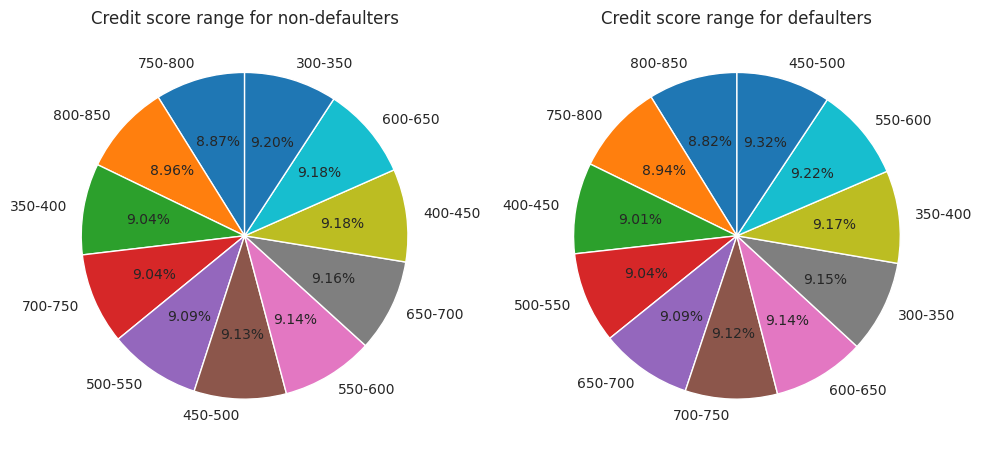

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Plot the first pie chart
axes[0].pie(credit_score_range_0, labels=credit_score_range_0.index, autopct='%1.2f%%', startangle=90)
axes[0].set_title('Credit score range for non-defaulters')

# Plot the second pie chart
axes[1].pie(credit_score_range_1, labels=credit_score_range_1.index, autopct='%1.2f%%', startangle=90)
axes[1].set_title('Credit score range for defaulters')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   age                    100000 non-null  int64   
 1   income                 100000 non-null  int64   
 2   loan_amount            100000 non-null  int64   
 3   credit_score           100000 non-null  int64   
 4   employment_status      100000 non-null  int64   
 5   default(y)             100000 non-null  int64   
 6   loan_term              100000 non-null  int64   
 7   interest_rate          100000 non-null  float64 
 8   debt_to_income_ratio   100000 non-null  float64 
 9   num_of_dependents      100000 non-null  int64   
 10  education_level        100000 non-null  int64   
 11  home_ownership         100000 non-null  int64   
 12  marital_status         100000 non-null  int64   
 13  credit_history_length  100000 non-null  int64   
 14  num_credit_lines     

###Statistical tests using SelectKBest for feature selection.

In [61]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

X = data.copy()  #independent variables
y = data['default(y)']    #target variable i.e price range

In [62]:
X = X.drop(['default(y)','credit_score_range'], axis=1)

In [63]:
y.head()

,default(y)
0,1
1,0
2,1
3,0
4,0


In [64]:
X.head()

,age,income,loan_amount,credit_score,employment_status,loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,education_level,home_ownership,marital_status,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses,age_range
0,38,71440,27069,689,1,36,9.937874,31.046101,0,1,2,1,7,6,1,1,25259,195208,6037,1
1,36,90200,14895,578,0,48,13.624882,21.845252,0,1,1,1,11,16,8,0,40761,152999,4064,1
2,47,85896,2613,352,0,12,6.676366,12.562405,1,0,0,0,24,2,2,0,34857,67487,2848,2
3,38,20121,3163,622,2,48,12.833366,17.144545,1,2,1,1,12,4,6,1,16048,98869,7721,1
4,44,77529,37731,615,1,12,4.111636,35.892430,3,1,1,2,27,7,5,0,5668,42397,8009,2


In [65]:
X.isnull().sum()

,0
age,0
income,0
loan_amount,0
credit_score,0
employment_status,0
loan_term,0
interest_rate,0
debt_to_income_ratio,0
num_of_dependents,0
education_level,0


In [66]:
#apply SelectKBest class using chi2 test to extract top 10 best features

BestFeatures = SelectKBest(score_func=chi2, k=10)
fit = BestFeatures.fit(X,y)

In [67]:
df_scores = pd.DataFrame(fit.scores_)
df_columns = pd.DataFrame(X.columns)

In [68]:
#concatenating two dataframes for better visualization

f_Scores = pd.concat([df_columns,df_scores],axis=1) # feature scores
f_Scores.columns = ['Specs','Score']

In [69]:
print(f_Scores)

                    Specs         Score
0                     age      0.445251
1                  income  15200.517672
2             loan_amount    805.604794
3            credit_score      7.228253
4       employment_status      2.078609
5               loan_term     57.501834
6           interest_rate      1.954516
7    debt_to_income_ratio      0.181065
8       num_of_dependents      1.769513
9         education_level      0.633726
10         home_ownership      1.616267
11         marital_status      0.033522
12  credit_history_length      2.257086
13       num_credit_lines      0.360002
14          late_payments      0.057386
15           bankruptcies      0.791978
16         annual_savings  15467.509971
17     retirement_savings  12947.442737
18       monthly_expenses      0.515844
19              age_range      0.137980


In [70]:
# Score value is directly proportional to the feature importance
# print 10 best features in descending order
print(f_Scores.nlargest(10,'Score'))

                    Specs         Score
16         annual_savings  15467.509971
1                  income  15200.517672
17     retirement_savings  12947.442737
2             loan_amount    805.604794
5               loan_term     57.501834
3            credit_score      7.228253
12  credit_history_length      2.257086
4       employment_status      2.078609
6           interest_rate      1.954516
8       num_of_dependents      1.769513


Trying Anova test instead of chi square test.




In [71]:
from sklearn.feature_selection import f_classif
BestFeatures_fclassif = SelectKBest(score_func=f_classif, k=10)
fit_fclassif = BestFeatures_fclassif.fit(X,y)

In [72]:
df_scores_flcassif = pd.DataFrame(fit.scores_)
df_columns_fclassif = pd.DataFrame(X.columns)

In [73]:
#concatenating two dataframes for better visualization

f_Scores_fclassif = pd.concat([df_columns_fclassif,df_scores_flcassif],axis=1) # feature scores
f_Scores_fclassif.columns = ['Specs','Score']

In [74]:
f_Scores_fclassif

,Specs,Score
0,age,0.445251
1,income,15200.517672
2,loan_amount,805.604794
3,credit_score,7.228253
4,employment_status,2.078609
5,loan_term,57.501834
6,interest_rate,1.954516
7,debt_to_income_ratio,0.181065
8,num_of_dependents,1.769513
9,education_level,0.633726


In [75]:
print(f_Scores_fclassif.nlargest(10,'Score'))

                    Specs         Score
16         annual_savings  15467.509971
1                  income  15200.517672
17     retirement_savings  12947.442737
2             loan_amount    805.604794
5               loan_term     57.501834
3            credit_score      7.228253
12  credit_history_length      2.257086
4       employment_status      2.078609
6           interest_rate      1.954516
8       num_of_dependents      1.769513


Both Chi square test and the Anova test are giving the same set of features for the top 10 scores list.

In [76]:
top_10 = pd.DataFrame(f_Scores_fclassif.nlargest(10,'Score'))
top_10

,Specs,Score
16,annual_savings,15467.509971
1,income,15200.517672
17,retirement_savings,12947.442737
2,loan_amount,805.604794
5,loan_term,57.501834
3,credit_score,7.228253
12,credit_history_length,2.257086
4,employment_status,2.078609
6,interest_rate,1.954516
8,num_of_dependents,1.769513


In [77]:
anova_top_features = top_10['Specs']
anova_top_features

,Specs
16,annual_savings
1,income
17,retirement_savings
2,loan_amount
5,loan_term
3,credit_score
12,credit_history_length
4,employment_status
6,interest_rate
8,num_of_dependents


In [78]:
anova_x = X[anova_top_features]
anova_x.head()

,annual_savings,income,retirement_savings,loan_amount,loan_term,credit_score,credit_history_length,employment_status,interest_rate,num_of_dependents
0,25259,71440,195208,27069,36,689,7,1,9.937874,0
1,40761,90200,152999,14895,48,578,11,0,13.624882,0
2,34857,85896,67487,2613,12,352,24,0,6.676366,1
3,16048,20121,98869,3163,48,622,12,2,12.833366,1
4,5668,77529,42397,37731,12,615,27,1,4.111636,3


Standardizing the features before building the model

In [79]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
x_scaled.head()

,age,income,loan_amount,credit_score,employment_status,loan_term,interest_rate,debt_to_income_ratio,num_of_dependents,education_level,home_ownership,marital_status,credit_history_length,num_credit_lines,late_payments,bankruptcies,annual_savings,retirement_savings,monthly_expenses,age_range
0,-0.351667,0.494857,0.109608,0.726401,0.627472,-0.001507,0.205788,0.090819,-1.408996,0.062504,0.896821,-0.464574,-0.952967,-0.733448,-1.215720,3.394855,0.002599,1.644025,0.286004,-0.562354
1,-0.509269,1.307221,-0.751586,0.026442,-0.615884,0.705875,1.316884,-0.704833,-1.408996,0.062504,-0.381503,-0.464574,-0.475045,1.094386,1.221053,-0.215617,1.089794,0.909434,-0.434065,-0.562354
2,0.357542,1.120845,-1.620420,-1.398699,-0.615884,-1.416270,-0.777081,-1.507576,-0.703563,-1.094766,-1.659826,-2.023235,1.078202,-1.464581,-0.867610,-0.215617,0.675732,-0.578787,-0.877858,0.215969
3,-0.351667,-1.727409,-1.581513,0.303903,1.870828,0.705875,1.078357,-1.111331,-0.703563,1.219774,-0.381503,-0.464574,-0.355565,-1.099015,0.524832,3.394855,-0.643392,-0.032626,0.900600,-0.562354
4,0.121139,0.758529,0.863842,0.259762,0.627472,-1.416270,-1.549974,0.509910,0.707302,0.062504,-0.381503,1.094086,1.436644,-0.550664,0.176722,-0.215617,-1.371368,-1.015445,1.005709,0.215969


###Feature importance using XGBoost Classifier


In [80]:
import xgboost
import matplotlib.pyplot as plt

model = xgboost.XGBClassifier()
model.fit(x_scaled,y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [81]:
print(model.feature_importances_)


[0.05232726 0.05228068 0.05354023 0.05385392 0.05198392 0.05034979
 0.05336805 0.05216848 0.05482298 0.0533994  0.04700482 0.05596681
 0.05011731 0.05132093 0.04844363 0.05957614 0.05198501 0.05337862
 0.05411202 0.        ]


In [82]:
xgb_scores = pd.DataFrame(model.feature_importances_)
xgb_columns = pd.DataFrame(X.columns)

In [83]:
xgb_Scores = pd.concat([xgb_columns,xgb_scores],axis=1) # feature scores
xgb_Scores.columns = ['Columns','Feature Importances']

In [84]:
print(xgb_Scores)

                  Columns  Feature Importances
0                     age             0.052327
1                  income             0.052281
2             loan_amount             0.053540
3            credit_score             0.053854
4       employment_status             0.051984
5               loan_term             0.050350
6           interest_rate             0.053368
7    debt_to_income_ratio             0.052168
8       num_of_dependents             0.054823
9         education_level             0.053399
10         home_ownership             0.047005
11         marital_status             0.055967
12  credit_history_length             0.050117
13       num_credit_lines             0.051321
14          late_payments             0.048444
15           bankruptcies             0.059576
16         annual_savings             0.051985
17     retirement_savings             0.053379
18       monthly_expenses             0.054112
19              age_range             0.000000


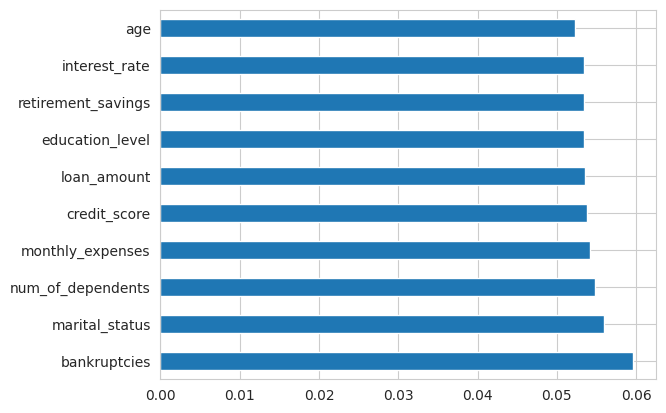

<Figure size 800x600 with 0 Axes>

In [85]:
#plot the graph of feature importances for better visualization

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.figure(figsize=(8,6))
plt.show()

Splitting the data into training and testing

In [86]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

Building a baseline model using Logistic Regression

In [87]:
from sklearn.linear_model import LogisticRegression

# Create a logistic regression model
model_lr = LogisticRegression()
# Train the model
model_lr.fit(x_train, y_train)

LogisticRegression()

In [88]:
# Make predictions on the test set
lr_y_pred_test = model.predict(x_test)
lr_y_pred_train = model.predict(x_train)


In [89]:
# Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
print("******************** classification_report********************")
print("*************** Train Data **************")
print(classification_report(y_train, lr_y_pred_train))
roc_auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:,1])
print("ROC AUC for train data: ",roc_auc_train)
print("")
print("*************** Test Data ***************")
print(classification_report(y_test, lr_y_pred_test))
roc_auc_test = roc_auc_score(y_test, model.predict_proba(x_test)[:,1])
print("ROC AUC for test data: ",roc_auc_test)

******************** classification_report********************
*************** Train Data **************
              precision    recall  f1-score   support

           0       0.71      0.71      0.71     39867
           1       0.71      0.71      0.71     40133

    accuracy                           0.71     80000
   macro avg       0.71      0.71      0.71     80000
weighted avg       0.71      0.71      0.71     80000

ROC AUC for train data:  0.7912621328974181

*************** Test Data ***************
              precision    recall  f1-score   support

           0       0.71      0.71      0.71     10039
           1       0.70      0.70      0.70      9961

    accuracy                           0.70     20000
   macro avg       0.70      0.70      0.70     20000
weighted avg       0.70      0.70      0.70     20000

ROC AUC for test data:  0.7842892390393258


In [90]:
print("Confusion matrix")
print(confusion_matrix(y_test, lr_y_pred_test))


Confusion matrix
[[7080 2959]
 [2956 7005]]


The model is not overfitting or underfitting but the accuracy score is great either.

Trying the baseline Logistic regression with the top 10 features from anova test

In [91]:
# Standaradizing the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled_anova = pd.DataFrame(scaler.fit_transform(anova_x), columns=anova_x.columns)
x_scaled_anova.head()

,annual_savings,income,retirement_savings,loan_amount,loan_term,credit_score,credit_history_length,employment_status,interest_rate,num_of_dependents
0,0.002599,0.494857,1.644025,0.109608,-0.001507,0.726401,-0.952967,0.627472,0.205788,-1.408996
1,1.089794,1.307221,0.909434,-0.751586,0.705875,0.026442,-0.475045,-0.615884,1.316884,-1.408996
2,0.675732,1.120845,-0.578787,-1.620420,-1.416270,-1.398699,1.078202,-0.615884,-0.777081,-0.703563
3,-0.643392,-1.727409,-0.032626,-1.581513,0.705875,0.303903,-0.355565,1.870828,1.078357,-0.703563
4,-1.371368,0.758529,-1.015445,0.863842,-1.416270,0.259762,1.436644,0.627472,-1.549974,0.707302


Spitting scaled data into train and test

In [92]:
anova_x_train, anova_x_test, anova_y_train, anova_y_test = train_test_split(x_scaled_anova, y, test_size=0.2, random_state=42)

In [93]:
model_lr_anova = LogisticRegression()
model_lr_anova.fit(anova_x_train, anova_y_train)

LogisticRegression()

In [94]:
lr_anova_y_pred_test = model_lr_anova.predict(anova_x_test)
lr_anova_y_pred_train = model_lr_anova.predict(anova_x_train)

In [95]:
print("******************** classification_report********************")
print("*************** Train Data **************")
print(classification_report(anova_y_train, lr_anova_y_pred_train))
roc_auc_train = roc_auc_score(anova_y_train, model_lr_anova.predict_proba(anova_x_train)[:,1])
print("ROC AUC for train data: ",roc_auc_train)
print("")
print("*************** Test Data ***************")
print(classification_report(anova_y_test, lr_anova_y_pred_test))
roc_auc_test = roc_auc_score(anova_y_test, model_lr_anova.predict_proba(anova_x_test)[:,1])
print("ROC AUC for test data: ",roc_auc_test)

******************** classification_report********************
*************** Train Data **************
              precision    recall  f1-score   support

           0       0.51      0.43      0.46     39867
           1       0.51      0.58      0.54     40133

    accuracy                           0.51     80000
   macro avg       0.51      0.51      0.50     80000
weighted avg       0.51      0.51      0.50     80000

ROC AUC for train data:  0.5090066517616644

*************** Test Data ***************
              precision    recall  f1-score   support

           0       0.50      0.42      0.46     10039
           1       0.50      0.57      0.53      9961

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.50      0.50      0.49     20000

ROC AUC for test data:  0.4970734104865735


In [96]:
print("Confusion matrix")
print(confusion_matrix(anova_y_test, lr_anova_y_pred_test))

Confusion matrix
[[4250 5789]
 [4261 5700]]


Feature selection using PCA

In [97]:
#Feature selection using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=11)

x_scaled_pca = pca.fit_transform(x_scaled)

In [98]:
x_scaled_pca

array([[-0.64223822, -0.82547087, -0.21111726, ...,  1.74453155,
        -0.24450953,  2.17990529],
       [-0.77779337, -0.55432223,  0.65569295, ...,  0.25555759,
         0.20789526, -0.7790563 ],
       [ 0.37489266,  1.26128087,  0.90096976, ..., -1.27381868,
         0.74226834,  0.53350871],
       ...,
       [ 1.29734157, -0.2135188 ,  2.08051557, ..., -0.54640492,
        -0.55196545,  0.2032307 ],
       [ 1.58769685, -0.01903544, -0.32892858, ..., -0.14870935,
        -0.82390815, -0.19355813],
       [-2.11392564, -0.30395903, -0.55226109, ...,  0.6941708 ,
         0.3359442 , -0.38559102]])

In [99]:
component_names = [f"PC{i+1}" for i in range(x_scaled_pca.shape[1])]
component_names

['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11']

In [100]:
#Convert to dataframe
x_scaled_pca_df = pd.DataFrame(x_scaled_pca, columns = component_names)
x_scaled_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,-0.642238,-0.825471,-0.211117,0.121594,0.719827,-0.279868,-2.499314,1.249184,1.744532,-0.244510,2.179905
1,-0.777793,-0.554322,0.655693,-0.102270,-1.080202,0.956372,-0.370698,-0.184609,0.255558,0.207895,-0.779056
2,0.374893,1.261281,0.900970,-1.634602,-0.588136,-0.121786,-0.023564,0.598842,-1.273819,0.742268,0.533509
3,-0.655842,-1.463256,-1.786499,-1.921463,1.653738,-0.950730,-0.185153,-0.886729,2.474065,-0.065157,1.365815
4,0.262731,1.920682,0.351215,0.601191,1.014813,0.733398,1.243841,-0.143064,-0.060287,0.167734,0.115833


In [101]:
# Create loadings
loadings = pd.DataFrame(
  pca.components_.T,  # transpose the matrix of loadings
  columns=component_names,  # so the columns are the principal components
  index=x_scaled.columns,  # and the rows are the original features
)
loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
age,0.706954,-0.000090,0.004413,-0.002067,-0.000605,-0.006880,-0.002547,0.000154,-0.003505,0.000410,-0.000864
income,0.002324,0.186778,0.420589,0.392948,-0.139153,0.252331,-0.122949,0.074978,0.087365,0.032281,-0.341471
loan_amount,0.003316,-0.133337,0.295255,0.220941,0.355849,-0.096016,0.148820,0.173167,-0.162719,0.406392,0.160955
credit_score,0.005798,-0.249312,0.200504,-0.082563,-0.274719,0.439500,0.015497,-0.179964,0.385527,-0.138903,0.254773
employment_status,-0.002410,0.333271,0.047615,-0.241736,0.246088,-0.181428,-0.023666,-0.049234,0.242166,0.271733,-0.145504


* Splitting the x_scaled_pca dataset into train and test.
* Applying the logistic regression model on the x_scaled_pca dataset.

In [102]:
# splitting the data
x_train_pca, x_test_pca, y_train_pca, y_test_pca = train_test_split(x_scaled_pca_df, y, test_size = 0.2, random_state=42, stratify=y)


In [103]:
# LR model
model_lr_pca = LogisticRegression()
model_lr_pca.fit(x_train_pca, y_train_pca)

LogisticRegression()

In [104]:
lr_pca_y_pred_test = model_lr_pca.predict(x_test_pca)
lr_pca_y_pred_train = model_lr_pca.predict(x_train_pca)

In [105]:
print("******************** classification_report********************")
print("*************** Train Data **************")
print(classification_report(y_train_pca, lr_pca_y_pred_train))
#roc_auc_train = roc_auc_score(y_train_pca, model_lr_pca.predict_proba(y_train_pca)[:,1])
#print("ROC AUC for train data: ",roc_auc_train)
print("")
print("*************** Test Data ***************")
print(classification_report(y_test_pca, lr_pca_y_pred_test))
#roc_auc_test = roc_auc_score(y_test_pca, model_lr_pca.predict_proba(y_test_pca)[:,1])
#print("ROC AUC for test data: ",roc_auc_test)

******************** classification_report********************
*************** Train Data **************
              precision    recall  f1-score   support

           0       0.51      0.45      0.48     39925
           1       0.51      0.56      0.53     40075

    accuracy                           0.51     80000
   macro avg       0.51      0.51      0.50     80000
weighted avg       0.51      0.51      0.50     80000


*************** Test Data ***************
              precision    recall  f1-score   support

           0       0.50      0.45      0.47      9981
           1       0.50      0.56      0.53     10019

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000



Build pipeline for decision tree, random forest and xgboost models using the anova_x dataset.

In [106]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


In [108]:
from sklearn.pipeline import Pipeline
for name, model in models.items():
    clf = Pipeline(steps=[
        ('classifier', model)
    ])
    clf.fit(anova_x_train, anova_y_train)
    anova_y_pred = clf.predict(anova_x_test)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(anova_y_test, anova_y_pred))


Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.50      0.50     10039
           1       0.50      0.50      0.50      9961

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.51      0.50     10039
           1       0.49      0.47      0.48      9961

    accuracy                           0.49     20000
   macro avg       0.49      0.49      0.49     20000
weighted avg       0.49      0.49      0.49     20000


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.47      0.48     10039
           1       0.49      0.51      0.50      9961

    accuracy                           0.49     20000
   macro avg     

Build pipeline using the pca dataset

In [109]:
from sklearn.pipeline import Pipeline
for name, model in models.items():
    clf = Pipeline(steps=[
        ('classifier', model)
    ])
    clf.fit(x_train_pca, y_train_pca)
    y_pred_pca = clf.predict(x_test_pca)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test_pca, y_pred_pca))


Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.50      0.50      9981
           1       0.50      0.50      0.50     10019

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.53      0.52      9981
           1       0.51      0.48      0.49     10019

    accuracy                           0.51     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.51      0.51      0.51     20000


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.49      0.49      9981
           1       0.50      0.50      0.50     10019

    accuracy                           0.49     20000
   macro avg     

In [111]:
# Models and hyperparameters
models = {
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "classifier__max_depth": [3, 5, 10, None],
            "classifier__min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__max_depth": [3, 5, 7],
            "classifier__learning_rate": [0.01, 0.1, 0.2]
        }
    }
}

In [112]:
# Run grid search for each model using anova_x and anova_y dataset

from tqdm import tqdm
from sklearn.model_selection import GridSearchCV
for name, cfg in models.items():
    print(f"\n🔍 Running Grid Search for {name}...")
    pipe = Pipeline([
        ("classifier", cfg["model"])
    ])
    grid = GridSearchCV(pipe, cfg["params"], cv=5, scoring="accuracy", n_jobs=-1)
    with tqdm(desc=f"{name} Progress...", total=len(cfg["params"])*3) as pbar:
      grid.fit(anova_x_train, anova_y_train)
      # Update the progress bar in each iteration
      for i in range(len(cfg["params"]) * 3):
        pbar.update(1)

    print(f"✅ Best Parameters for {name}: {grid.best_params_}")
    anova_y_pred = grid.predict(anova_x_test)
    print(f"\n📊 Classification Report for {name}:\n")
    print(classification_report(anova_y_test, anova_y_pred))


🔍 Running Grid Search for Decision Tree...


Decision Tree Progress...: 100%|██████████| 6/6 [00:46<00:00,  7.83s/it]


✅ Best Parameters for Decision Tree: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10}

📊 Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.51      0.37      0.43     10039
           1       0.50      0.63      0.56      9961

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000


🔍 Running Grid Search for Random Forest...


Random Forest Progress...: 100%|██████████| 9/9 [13:49<00:00, 92.18s/it]   


✅ Best Parameters for Random Forest: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

📊 Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.49      0.51      0.50     10039
           1       0.49      0.47      0.48      9961

    accuracy                           0.49     20000
   macro avg       0.49      0.49      0.49     20000
weighted avg       0.49      0.49      0.49     20000


🔍 Running Grid Search for XGBoost...


XGBoost Progress...: 100%|██████████| 9/9 [00:50<00:00,  5.62s/it]

✅ Best Parameters for XGBoost: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}

📊 Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.49      0.41      0.45     10039
           1       0.49      0.57      0.53      9961

    accuracy                           0.49     20000
   macro avg       0.49      0.49      0.49     20000
weighted avg       0.49      0.49      0.49     20000



In [113]:
# Run grid search for each model using x_scaled_pca dataset

from tqdm import tqdm
from sklearn.model_selection import GridSearchCV
for name, cfg in models.items():
    print(f"\n🔍 Running Grid Search for {name}...")
    pipe = Pipeline([
        ("classifier", cfg["model"])
    ])
    grid = GridSearchCV(pipe, cfg["params"], cv=5, scoring="accuracy", n_jobs=-1)
    with tqdm(desc=f"{name} Progress...", total=len(cfg["params"])*3) as pbar:
      grid.fit(x_train_pca, y_train_pca)
      # Update the progress bar in each iteration
      for i in range(len(cfg["params"]) * 3):
        pbar.update(1)

    print(f"✅ Best Parameters for {name}: {grid.best_params_}")
    y_pred_pca = grid.predict(x_test_pca)
    print(f"\n📊 Classification Report for {name}:\n")
    print(classification_report(y_test_pca, y_pred_pca))


🔍 Running Grid Search for Decision Tree...


Decision Tree Progress...: 100%|██████████| 6/6 [01:30<00:00, 15.05s/it]


✅ Best Parameters for Decision Tree: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2}

📊 Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.50      0.55      0.53      9981
           1       0.51      0.46      0.48     10019

    accuracy                           0.51     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.51      0.51      0.51     20000


🔍 Running Grid Search for Random Forest...


Random Forest Progress...: 100%|██████████| 9/9 [24:32<00:00, 163.64s/it]   


✅ Best Parameters for Random Forest: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

📊 Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.50      0.55      0.52      9981
           1       0.50      0.45      0.48     10019

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000


🔍 Running Grid Search for XGBoost...


XGBoost Progress...: 100%|██████████| 9/9 [01:02<00:00,  6.93s/it]

✅ Best Parameters for XGBoost: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 50}

📊 Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.50      0.43      0.47      9981
           1       0.50      0.57      0.54     10019

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.50      0.50      0.50     20000

